In [1]:
import pandas as pd
from os.path import expanduser as ospath
import seaborn as sns
from matplotlib import pyplot as plt

import numpy as np
import ruptures as rpt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from scipy.optimize import minimize

import warnings
warnings.filterwarnings('ignore')

filepaths = [
    '~/Documents/Работа/Reology analysis/Реология 4Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 5Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 6Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 7Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 8Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 9Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 10Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 11Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 12Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 14Т.XLSX'
]

#расчет интенсивности напряжений
def sigma_i(sigma_1, sigma_2):
    sigma_i = 1/(2**0.5) * (
        (sigma_1 - sigma_2) ** 2 + (sigma_2-sigma_2) ** 2 + (sigma_2-sigma_1) ** 2
    ) ** 0.5
    return sigma_i

#расчет интенсивности деформаций
def e_i(e_1, e_3):
    e_i = 2 ** 0.5 / 3 * (
    (e_1 - e_3) ** 2 + (e_3 - e_3) ** 2 + (e_3 - e_1) ** 2
    ) ** 0.5
    return e_i

#подготовка данных в таблице
def prepare_data(data):
    data.drop(index=[0,1], inplace=True)
    data.drop(columns=data.columns[0], axis=1, inplace=True)
    data.columns = ['time', 'sigma_2', 'sigma_1', 'e1', 'e3']
    for col in data.columns:
        data[col] = data[col].astype('float64')
    data['time'] = data['time'] / 24
    data['e_i'] = e_i(data['e1'], data['e3'])
    data['s_i'] = sigma_i(data['sigma_2'], data['sigma_1'])

#расчет приращения деформаций по времени
def find_de_dt(data):
    s_int = data['s_i'].max()
    time = np.array(data['time'])
    e_i = np.array(data['e_i'])
    model = "l2"
    algo = rpt.Pelt(model=model, min_size=3, jump=1).fit(e_i)
    my_bkps = algo.predict(pen=0.0001)

    linear_section_start = my_bkps[0]
    x_linear = time[linear_section_start:].astype('float64')
    y_linear = e_i[linear_section_start:].astype('float64')
    try:
        coefficients = np.polyfit(x_linear, y_linear, 1)
        value = coefficients[0]
    except:
        value = None
    return value, s_int

#обработка данных
def analyze_all_data(file_paths):
    de_dt = []
    s_i =[]
    s_1 = []
    s_2 = []
    for path in file_paths:
        data = pd.read_excel(ospath(path), None)
        for table in data:
            prepare_data(data[table])
            s_1.append(data[table]['sigma_1'].max())
            s_2.append(data[table]['sigma_2'].max())
            de_value, s_int_value = find_de_dt(data[table])
            de_dt.append(de_value)
            s_i.append(s_int_value)
        print(path, '- ✅')
    return de_dt, s_i, s_1, s_2

de_dt, s_i, s_1, s_2 = analyze_all_data(filepaths)

de_si = pd.DataFrame()
de_si['s_i'] = s_i
de_si['de_dt'] = de_dt

de_si = de_si.dropna().sort_values(by='s_i').reset_index(drop=True)

de_si['s_i'] = de_si['s_i'].apply(round)
grouped = de_si.groupby(['s_i']).reset_index().mean()

#определение коэффициента N
de_si.plot(x ='s_i', y = 'de_dt', kind = 'scatter')
log_x = np.log(grouped['s_i'])
log_y = np.log(grouped['de_dt'])

coefficients = np.polyfit(log_x, log_y, 1)

a = np.exp(coefficients[1])
n = coefficients[0]

x = np.array(grouped['s_i'])
y = a * x ** n
plt.plot(x, y, 'r-', label='Fitted Curve')
plt.title('Fitted Curve: y = {:.10f} * x^({:.3f})'.format(a, n))

plt.show()

def custom_equation(x, A, m):
    n = 2.964428890433537
    y = A / (m + 1) * sig_int ** n * x ** (m + 1)
    return y


def objective_function(parameters, x, y):
    predicted_values = custom_equation(x, *parameters)
    
    residuals = predicted_values - y
    
    objective = np.sum(residuals**2)
    
    return objective


def optimize_curve(params):
    initial_guess = params

    result = minimize(objective_function, initial_guess, args=(x, y))

    optimal_parameters = result.x

    return optimal_parameters
        
        
coeff_a = []
coeff_m = []
for path in filepaths:
    data = pd.read_excel(ospath(path), None)
    for table in data:
        prepare_data(data[table])
        x = np.array(data[table]['time'])
        sig_int = data[table]['s_i'].max()
        y = np.array(data[table]['e_i'])
        
        optimal_parameters = [a, -0.5]
        
        new_params = optimize_curve(optimal_parameters)
        i = 0
        while all(x != y for x, y in zip(optimal_parameters, new_params)):
            optimal_parameters = new_params
            new_params = optimize_curve(optimal_parameters)
            i += 1
        else:
            optimal_parameters = new_params
            
        coeff_a.append(optimal_parameters[0])
        coeff_m.append(optimal_parameters[1])
        

        fitted_curve = custom_equation(x, *optimal_parameters)

        plt.plot(x, y, 'b.', label='Data')
        plt.plot(x, fitted_curve, 'r-', label='Fitted Curve')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'{path}\n{optimal_parameters}')
        plt.legend()
        plt.show()

a = pd.Series(coeff_a).mean()
m = pd.Series(coeff_m).mean()

print(f'A = {a}, n = {n}, m = {m}')

~/Documents/Работа/Reology analysis/Реология 4Т.XLSX - ✅
~/Documents/Работа/Reology analysis/Реология 5Т.XLSX - ✅
~/Documents/Работа/Reology analysis/Реология 6Т.XLSX - ✅


TimeoutError: [Errno 60] Operation timed out

In [2]:
import pandas as pd
from os.path import expanduser as ospath
import seaborn as sns
from matplotlib import pyplot as plt

import numpy as np
import ruptures as rpt

from scipy.optimize import minimize

import warnings
warnings.filterwarnings('ignore')

Загрузим результаты лабораторный испытаний керна каменной соли на реологию.

In [3]:
filepaths = [
    '~/Documents/Работа/Reology analysis/Реология 4Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 5Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 6Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 7Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 8Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 9Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 10Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 11Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 12Т.XLSX',
    '~/Documents/Работа/Reology analysis/Реология 14Т.XLSX'
]

Создадим функцию для расчета интенсивности напряжений.
Формула для определения интенсивности напряжений:

$$
S_i = \frac{1}{\sqrt{2}} * \sqrt{(S_1 - S_2)^2 + (S_2 - S_3)^2 + (S_3 - S_1)^2}
$$

Поскольку $S_2 = S_3$, в формуле это и задано.

In [4]:
#расчет интенсивности напряжений
def sigma_i(sigma_1, sigma_2):
    sigma_i = 1/(2**0.5) * (
        (sigma_1 - sigma_2) ** 2 + (sigma_2-sigma_2) ** 2 + (sigma_2-sigma_1) ** 2
    ) ** 0.5
    return sigma_i

Данная функция определяет интенсивность деформаций по следующей формуле:

$$
E_i = \frac{\sqrt{2}}{3} * \sqrt{(E_1 - E_3)^2 + (E_2 - E_3)^2 + (E_3 - E_1)^2}
$$

In [5]:
#расчет интенсивности деформаций
def e_i(e_1, e_3):
    e_i = 2 ** 0.5 / 3 * (
    (e_1 - e_3) ** 2 + (e_3 - e_3) ** 2 + (e_3 - e_1) ** 2
    ) ** 0.5
    return e_i

С помощью данной функции, происходит обработка самой таблицы:
- заменяются названия столбцов
- все значения приводятся к значениям с плавающей запятой
- время переводится из часов в сутки
- определяется интенсивность напряжений и деформаций с помощью формул, описанных выше

In [6]:
#подготовка данных в таблице
def prepare_data(data):
    data.drop(index=[0,1], inplace=True)
    data.drop(columns=data.columns[0], axis=1, inplace=True)
    data.columns = ['time', 'sigma_2', 'sigma_1', 'e1', 'e3']
    for col in data.columns:
        data[col] = data[col].astype('float64')
    data['time'] = data['time'] / 24
    data['e_i'] = e_i(data['e1'], data['e3'])
    data['s_i'] = sigma_i(data['sigma_2'], data['sigma_1'])

С помощью данной функции рассчитывается изменение деформаций во времени:
- определяется максимальная интенсивность деформаций
- далее с помощью метода Pelt (подробнее здесь: https://centre-borelli.github.io/ruptures-docs/user-guide/detection/pelt/) определяется прямолинейный участок кривой и коэффициент, от которого зависит наклон этого участка.

В результате, мы получаем пару значений: значение максимальной интенсивности напряжений в эксперименте и скорость изменения интенсивности деформаций.

In [14]:
#расчет приращения деформаций по времени
def find_de_dt(data):
    s_int = data['s_i'].max()
    time = np.array(data['time'])
    e_i = np.array(data['e_i'])
    model = "l2"
    algo = rpt.Pelt(model=model, min_size=1, jump=1).fit(e_i)
    my_bkps = algo.predict(pen=0.0001)

    linear_section_start = my_bkps[0]
    x_linear = time[linear_section_start:].astype('float64')
    y_linear = e_i[linear_section_start:].astype('float64')
    try:
        coefficients = np.polyfit(x_linear, y_linear, 1)
        value = coefficients[0]
    except Exception as e:
        print(f"Error in find_de_dt: {e}")
        value = None
    return value, s_int

С помощью функции ниже обрабатываются все листы во всех заданных таблицах.

In [15]:
#обработка данных
def analyze_all_data(file_paths):
    de_dt = []
    s_i =[]
    s_1 = []
    s_2 = []
    for path in file_paths:
        data = pd.read_excel(ospath(path), None)
        for table in data:
            prepare_data(data[table])
            s_1.append(data[table]['sigma_1'].max())
            s_2.append(data[table]['sigma_2'].max())
            de_value, s_int_value = find_de_dt(data[table])
            de_dt.append(de_value)
            s_i.append(s_int_value)
        print(path, '- ✅')
    return de_dt, s_i, s_1, s_2

Обработка таблиц:

In [16]:
de_dt, s_i, s_1, s_2 = analyze_all_data(filepaths)

~/Documents/Работа/Reology analysis/Реология 4Т.XLSX - ✅
Error in find_de_dt: expected non-empty vector for x
~/Documents/Работа/Reology analysis/Реология 5Т.XLSX - ✅
~/Documents/Работа/Reology analysis/Реология 6Т.XLSX - ✅
~/Documents/Работа/Reology analysis/Реология 7Т.XLSX - ✅
Error in find_de_dt: expected non-empty vector for x
~/Documents/Работа/Reology analysis/Реология 8Т.XLSX - ✅
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
Error in find_de_dt: expected non-empty vector for x
~/Documents/Работа/Reology

Создание новой таблицы, содержащей лишь значения интенсивности напряжений и скорости изменения деформаций.

In [17]:
de_si = pd.DataFrame()
de_si['s_i'] = s_i
de_si['de_dt'] = de_dt

Количество получившихся значений (равно количеству экспериментов)

In [18]:
len(de_dt)

199

Форматирование таблицы.
Группировка по интенсивности напряжений, скорость приращения деформаций рассчитывается как средняя всех экспериментов с данной интенсинвостью напряжений.

In [19]:
de_si = de_si.dropna().sort_values(by='s_i').reset_index(drop=True)

de_si['s_i'] = de_si['s_i'].apply(round)
grouped = de_si.groupby(['s_i']).mean()

Полученная таблица:

In [20]:
grouped = grouped.reset_index()
grouped

,s_i,de_dt
0,11,0.000663
1,12,0.000222
2,14,0.000424
3,15,0.000281
4,16,0.000855
5,17,0.001006
6,18,0.000881
7,20,0.001626
8,21,0.002793
9,23,0.002933


Теперь определяется коэффициент n.
График, построенный по значениям выше, описывается с помощью уравнения $$\varepsilon_i^\cdot = a \cdot \sigma^n_i  $$

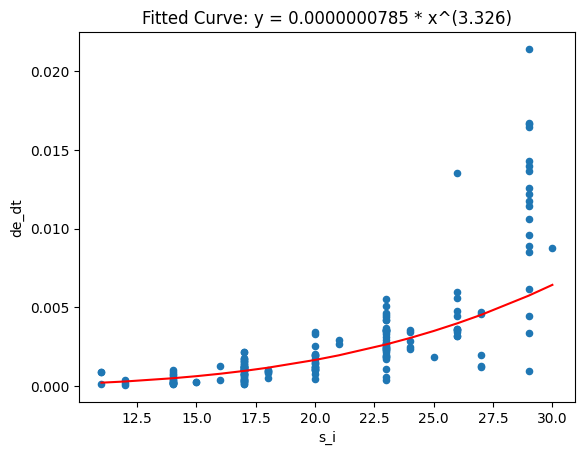

In [21]:
#определение коэффициента N
de_si.plot(x ='s_i', y = 'de_dt', kind = 'scatter')
log_x = np.log(grouped['s_i'])
log_y = np.log(grouped['de_dt'])

coefficients = np.polyfit(log_x, log_y, 1)

a = np.exp(coefficients[1])
n = coefficients[0]

x = np.array(grouped['s_i'])
y = a * x ** n
plt.plot(x, y, 'r-', label='Fitted Curve')
plt.title('Fitted Curve: y = {:.10f} * x^({:.3f})'.format(a, n))

plt.show()


Полученный результат:

In [22]:
print(a, n)

7.852109909598014e-08 3.3262049379405894


Далее задается полное уравнение реологического поведения соли $ \frac {A}{m+1}\sigma^nt^{m+1}$.
Далее с помощью градиентного спуска определяюься оптимальные коэффициенты, чтобы полученная кривая была как можно ближе к экспериментальной.
В результате, можно увидеть построенные кривые и полученные коэффициенты для каждого эксперимента.

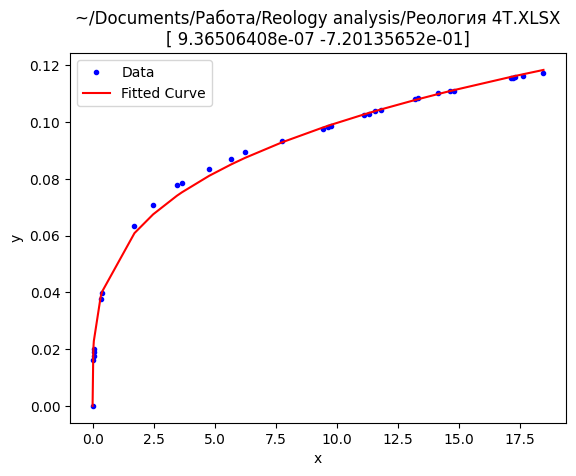

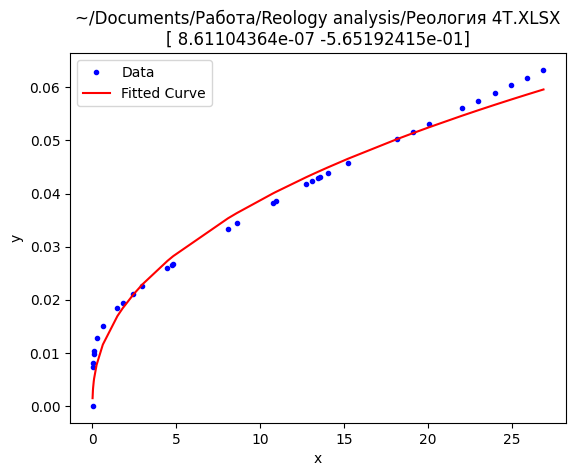

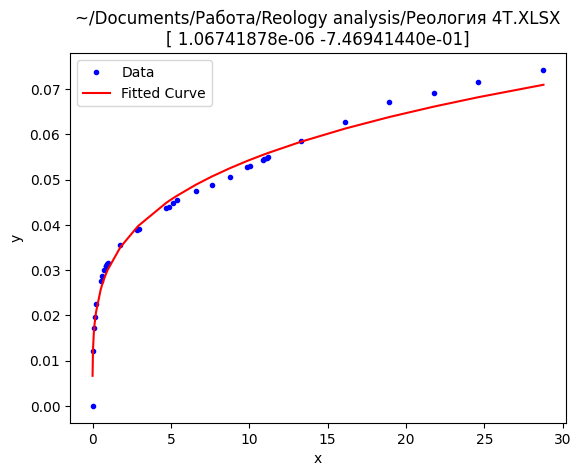

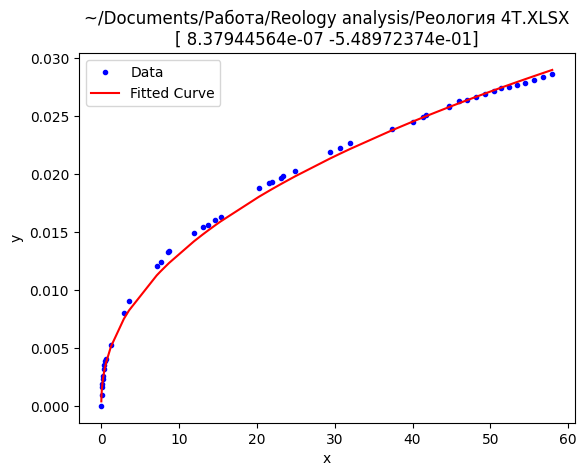

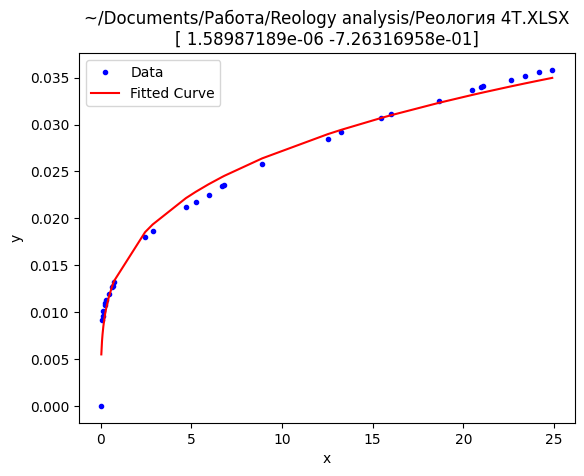

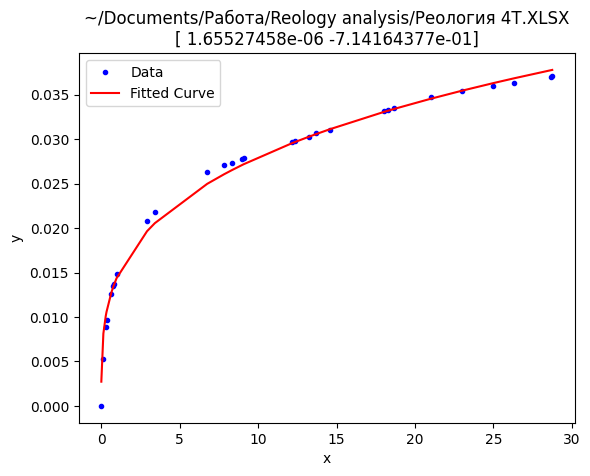

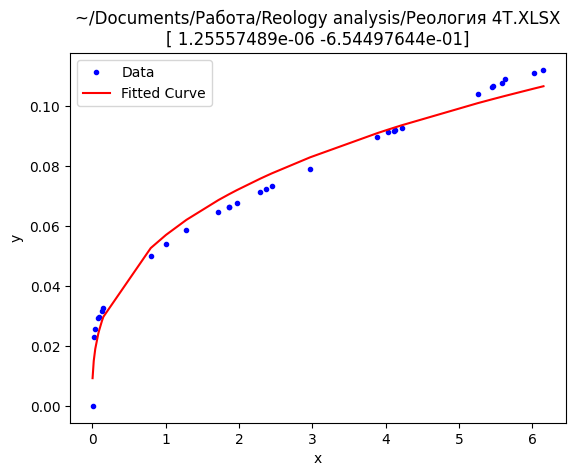

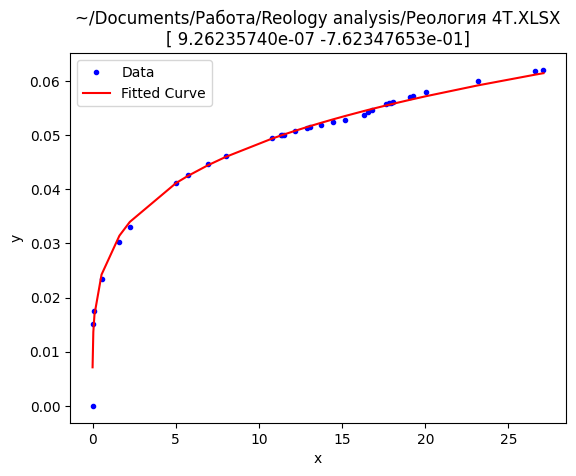

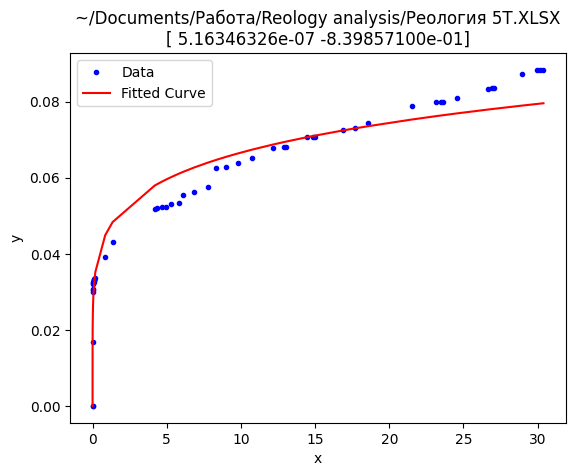

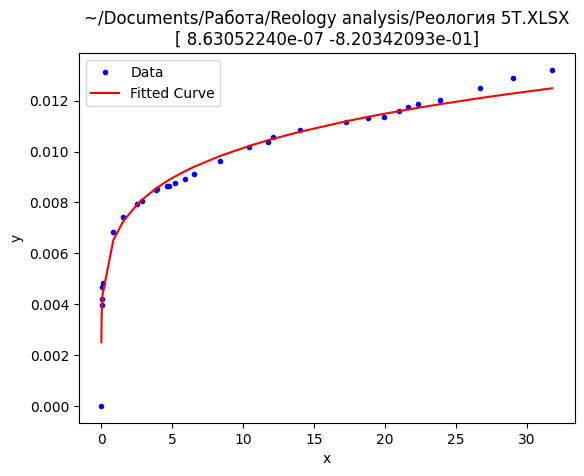

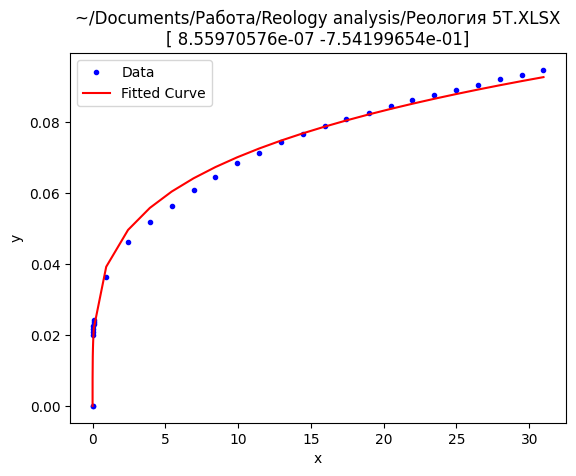

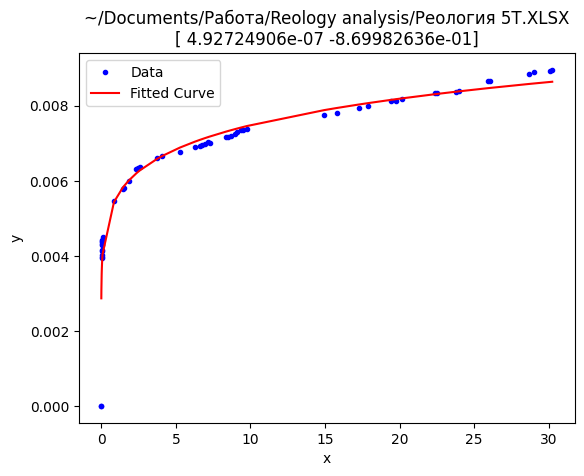

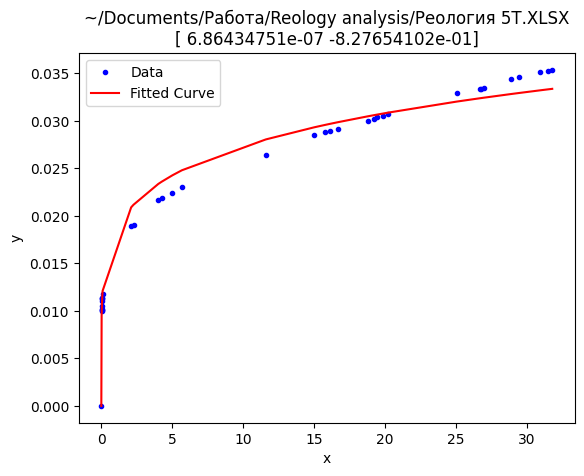

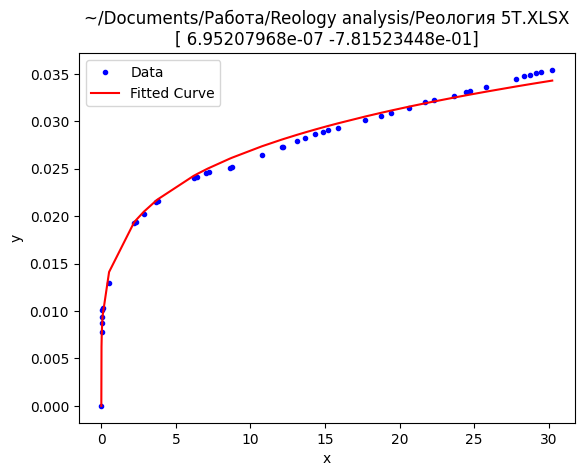

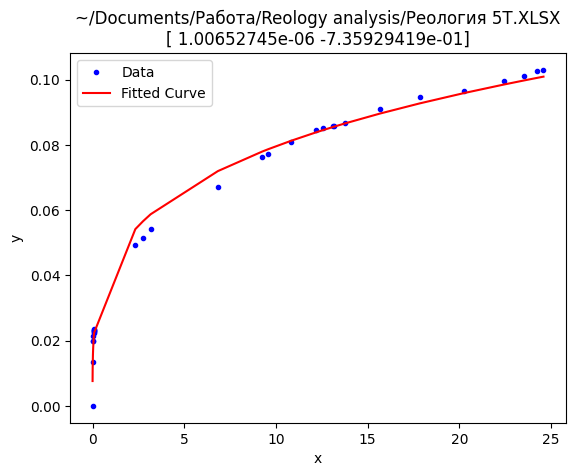

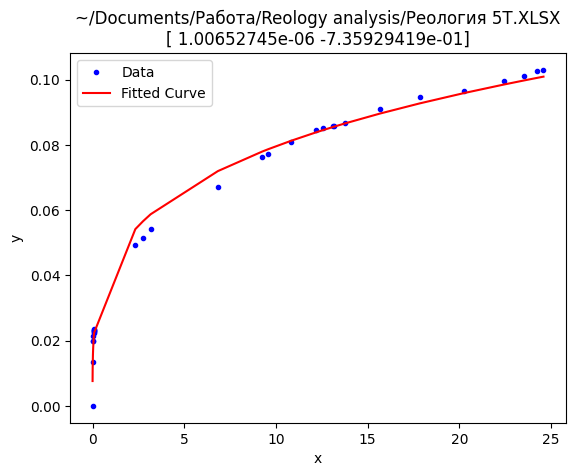

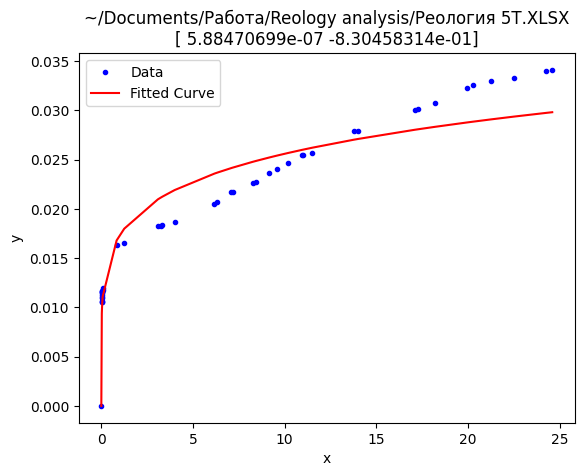

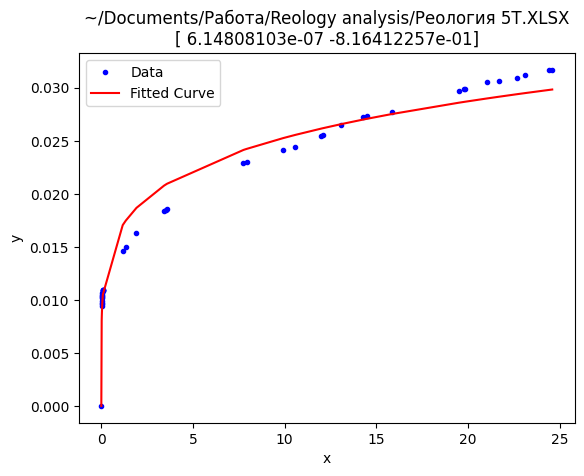

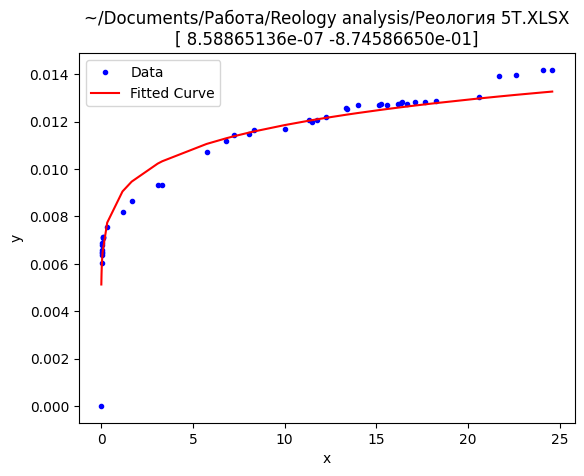

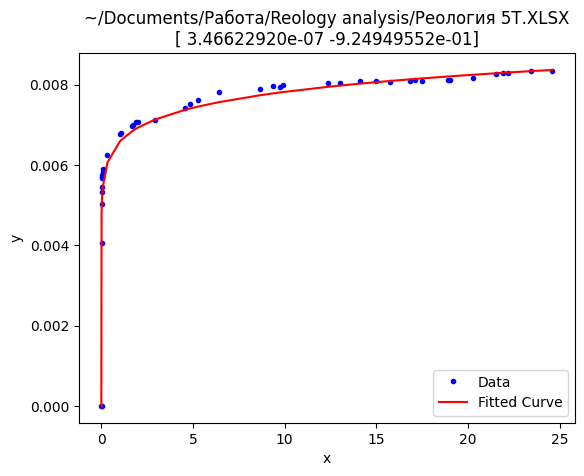

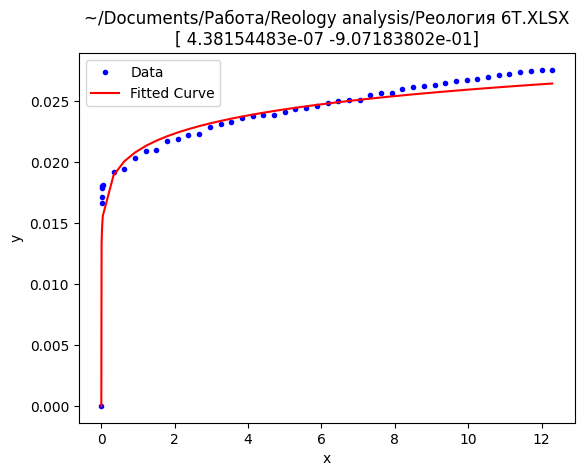

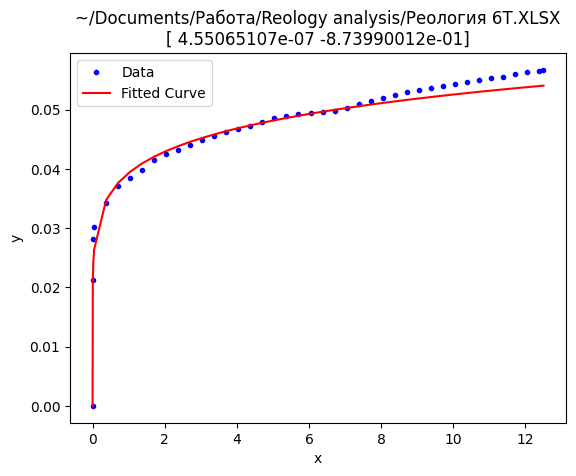

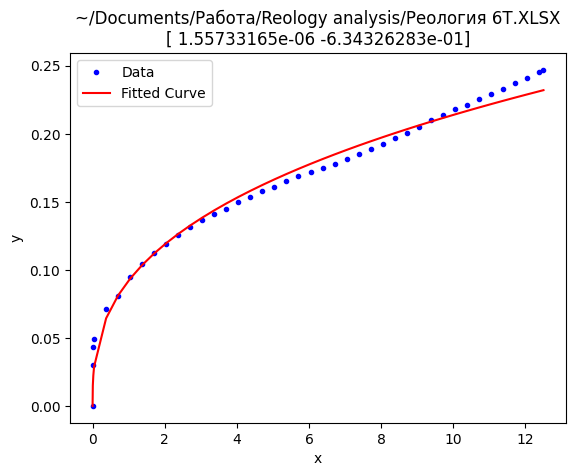

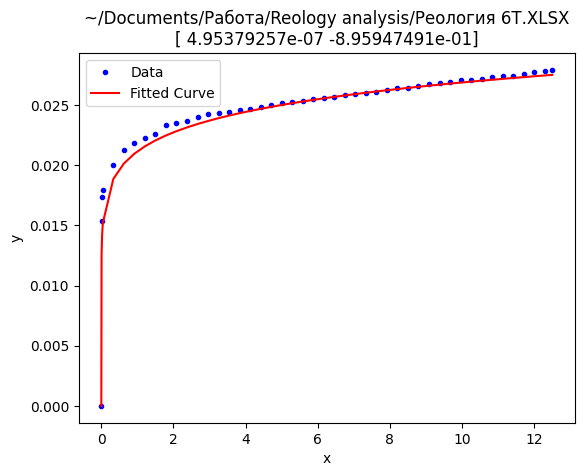

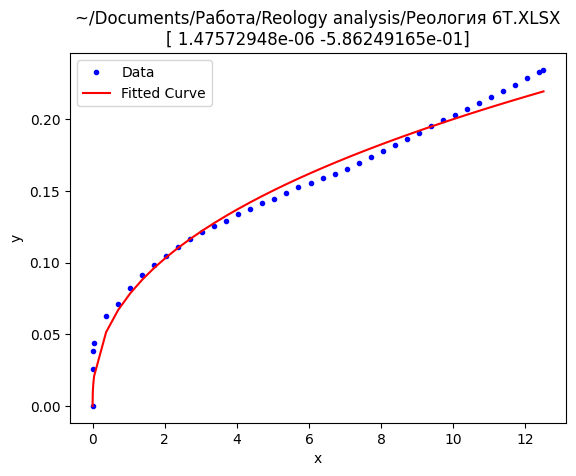

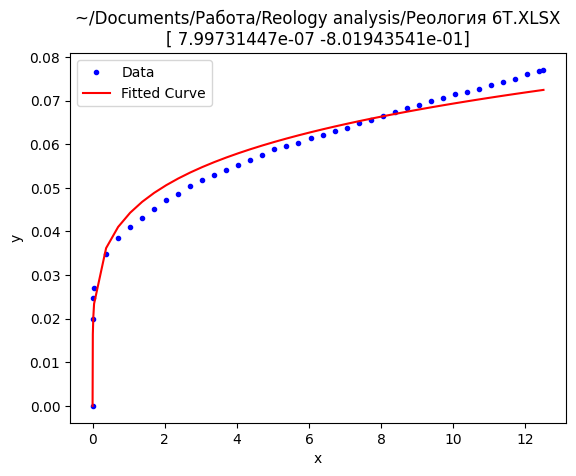

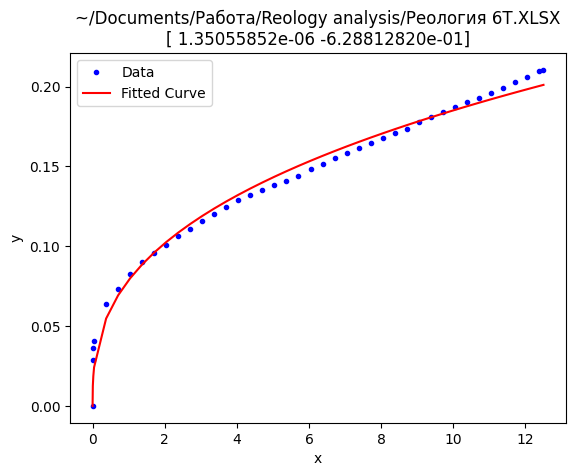

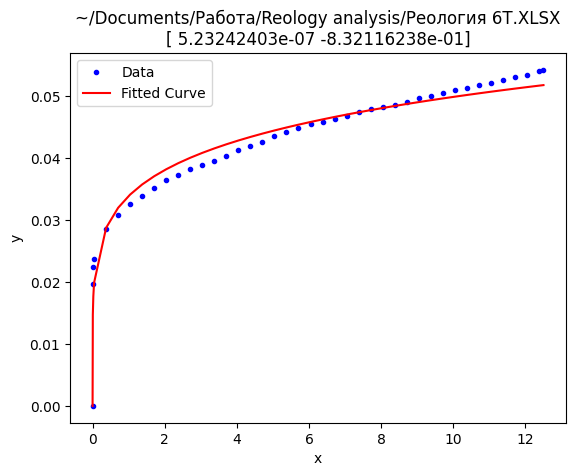

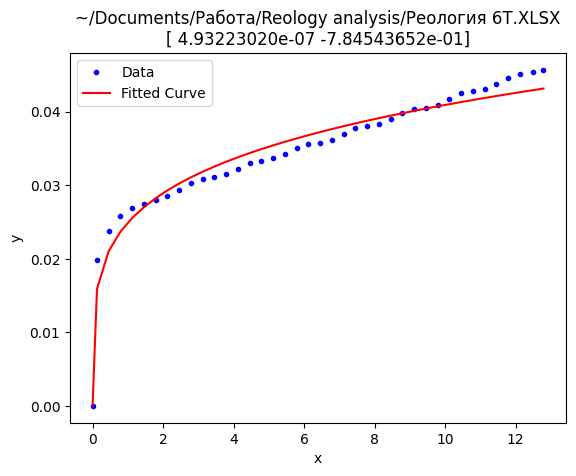

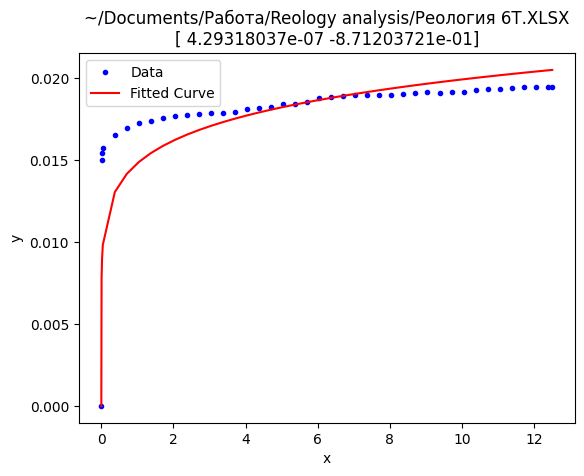

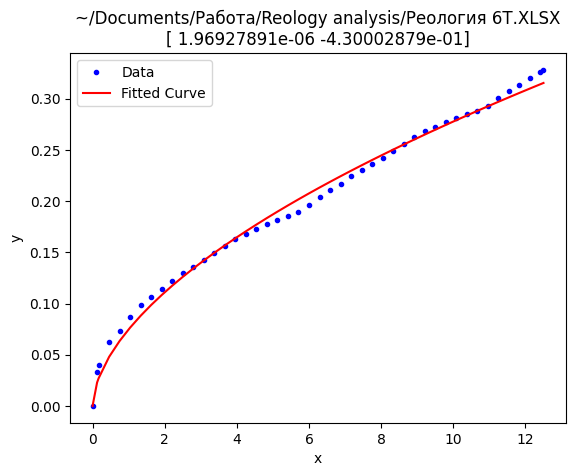

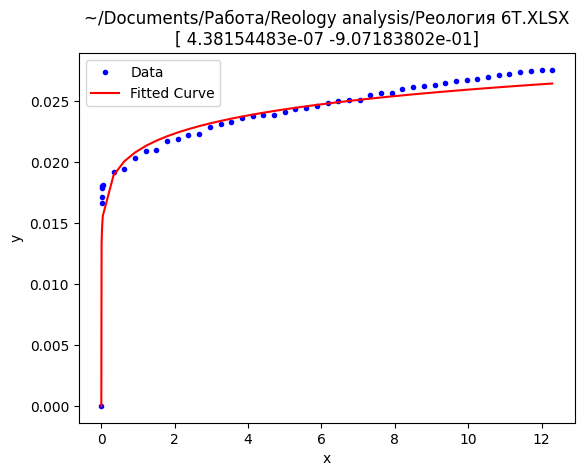

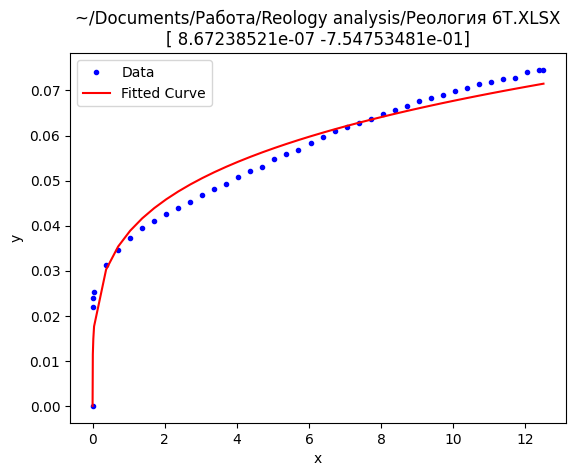

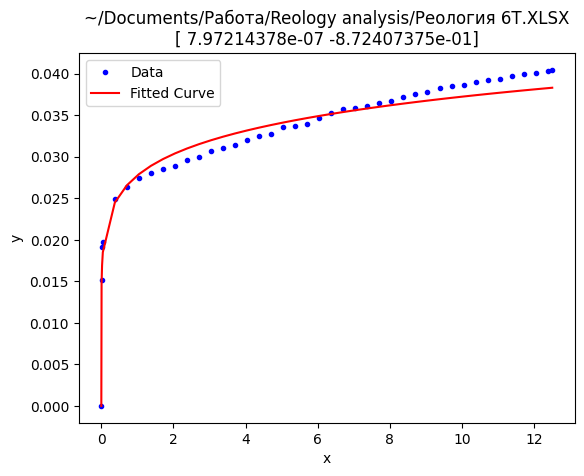

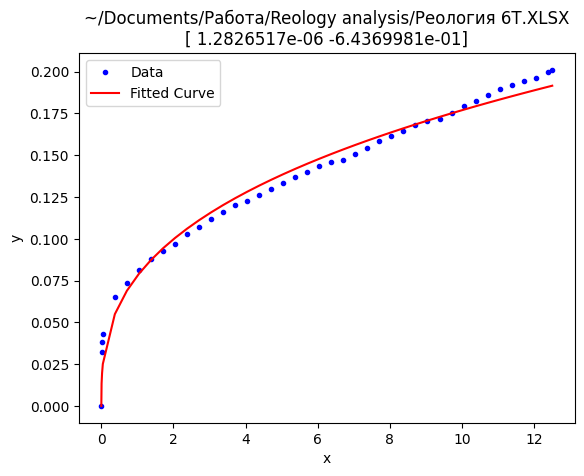

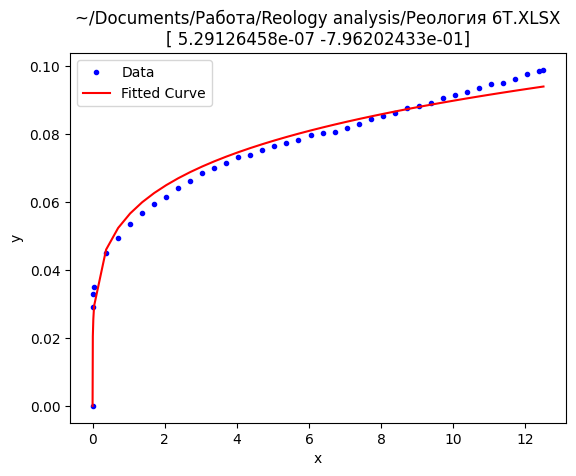

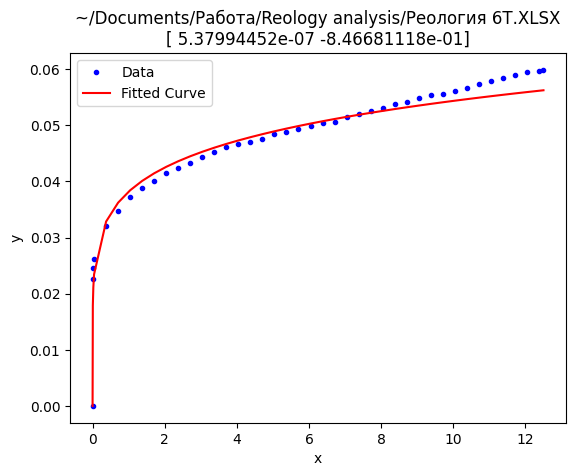

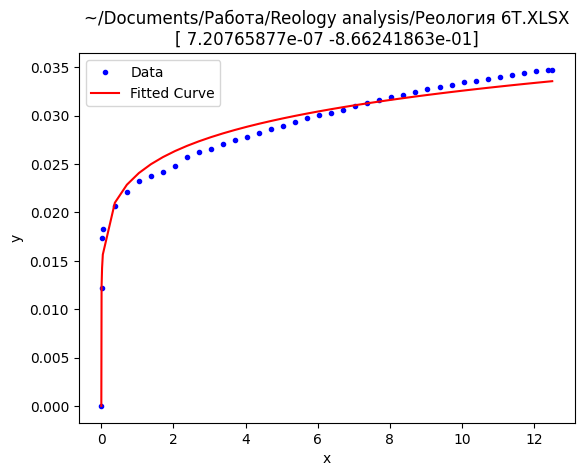

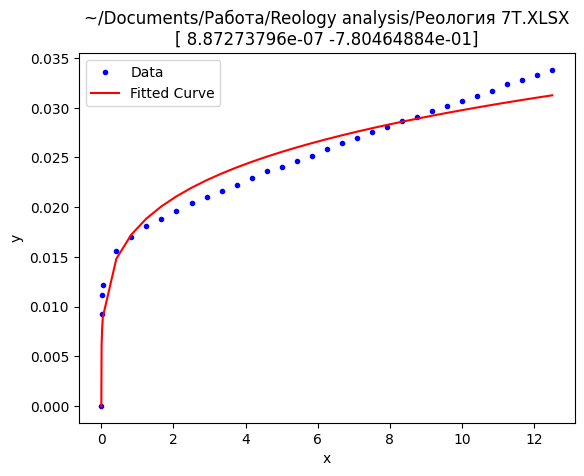

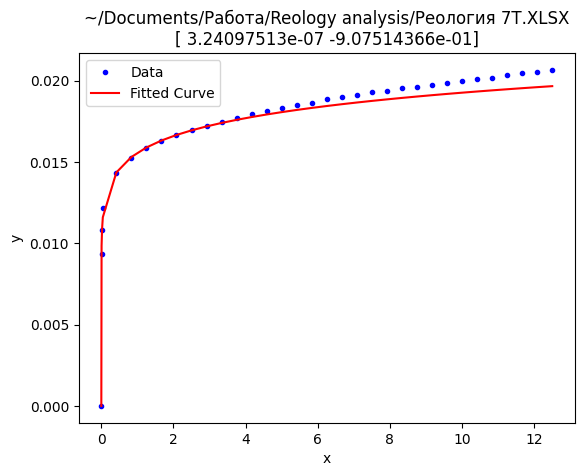

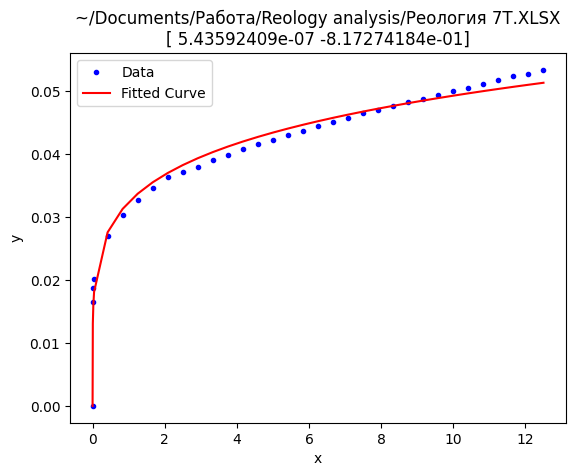

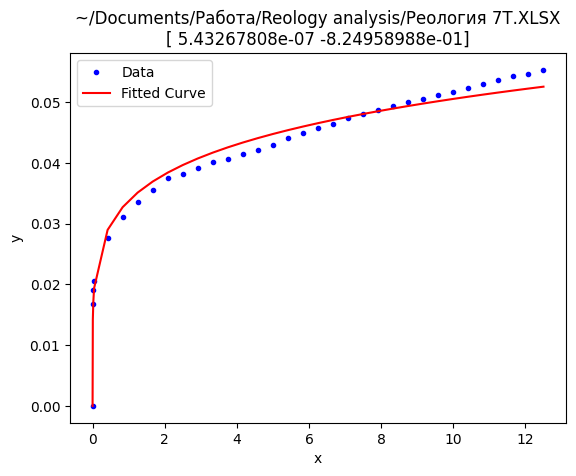

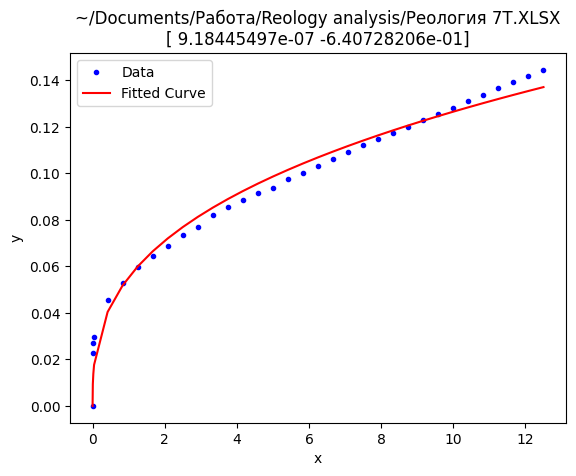

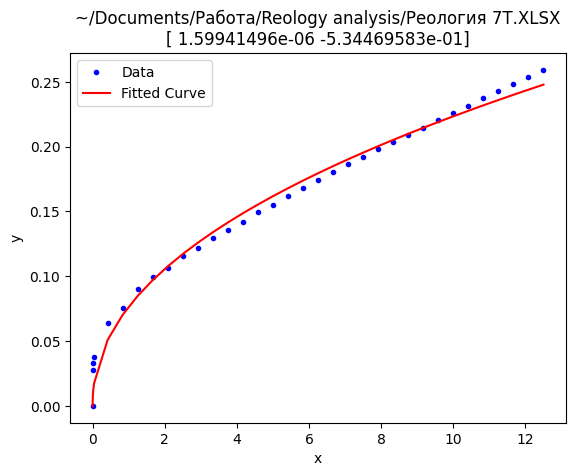

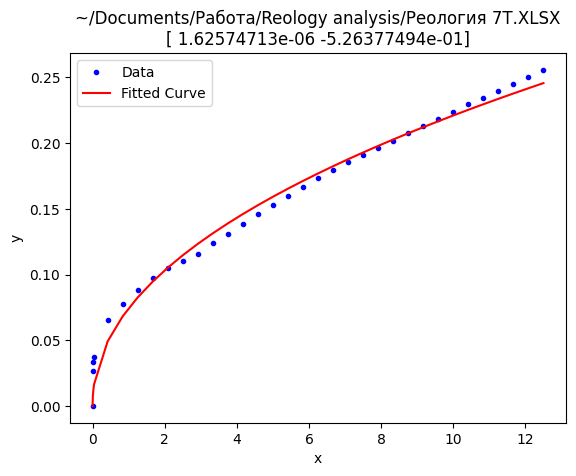

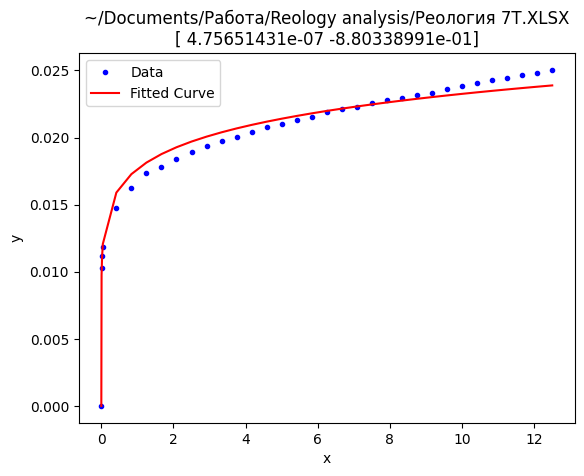

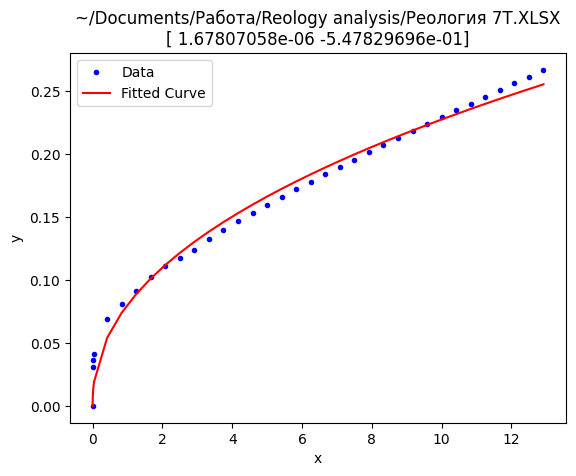

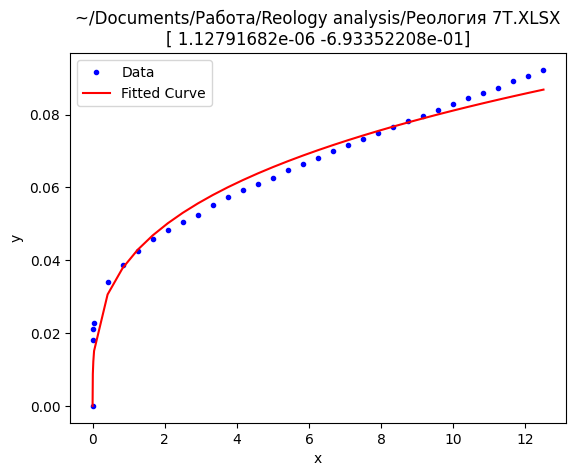

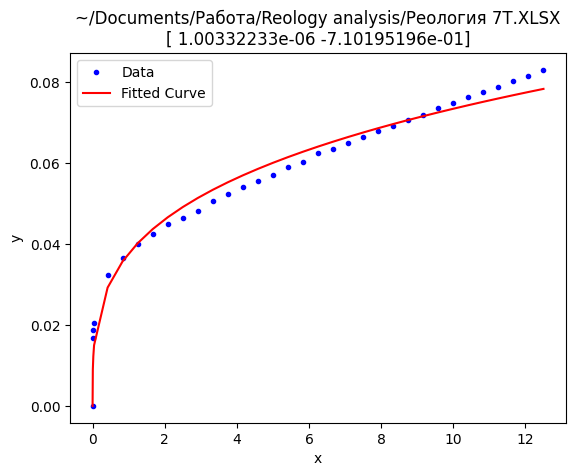

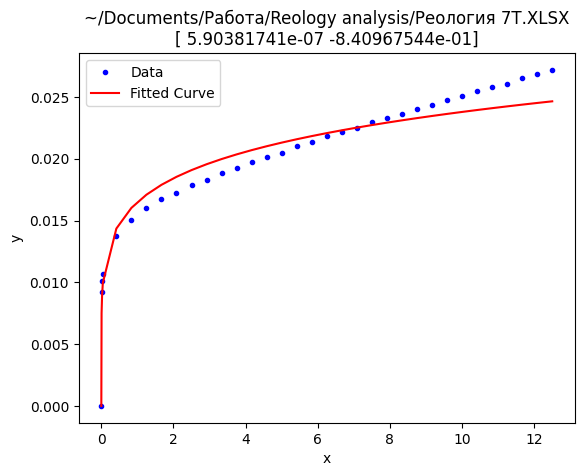

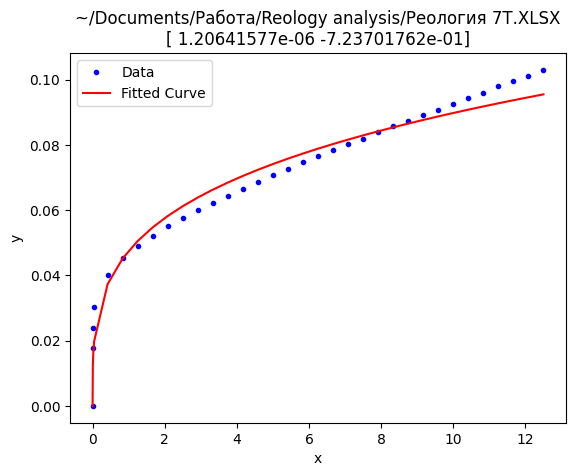

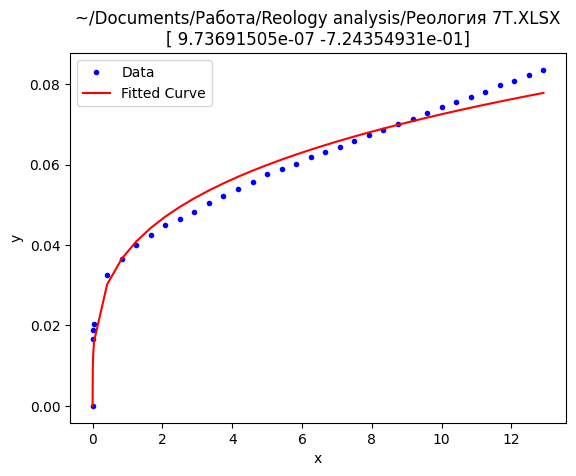

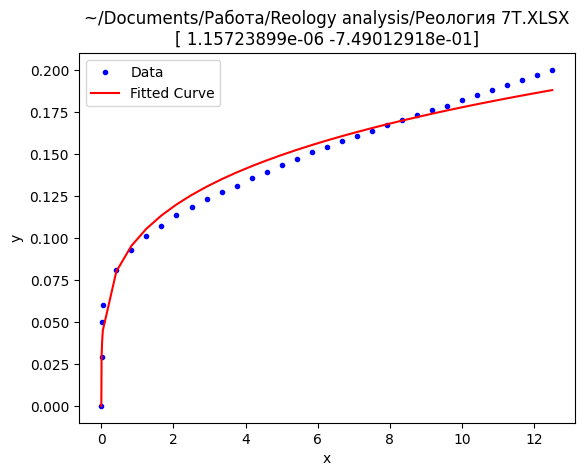

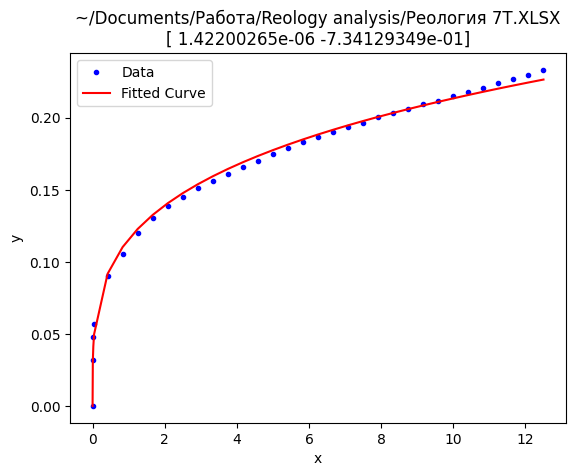

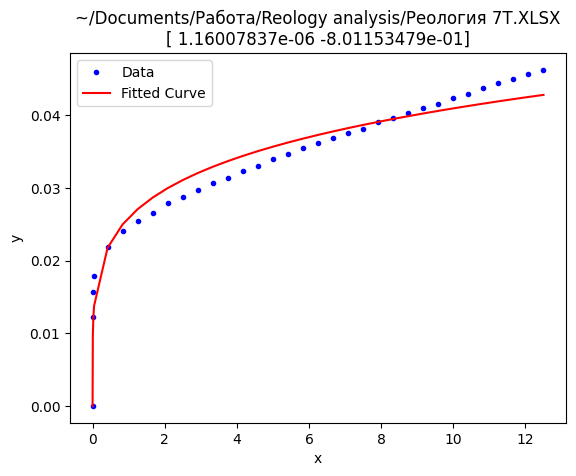

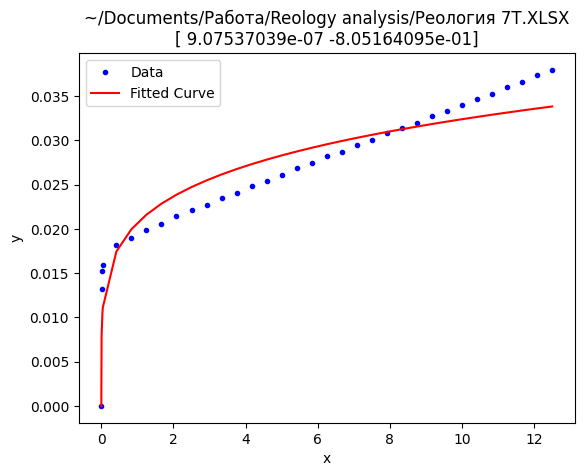

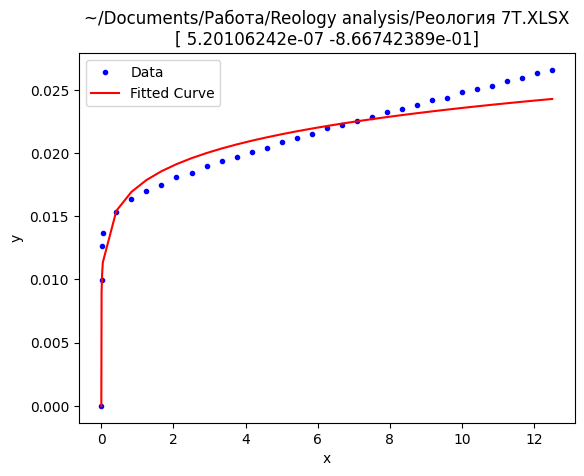

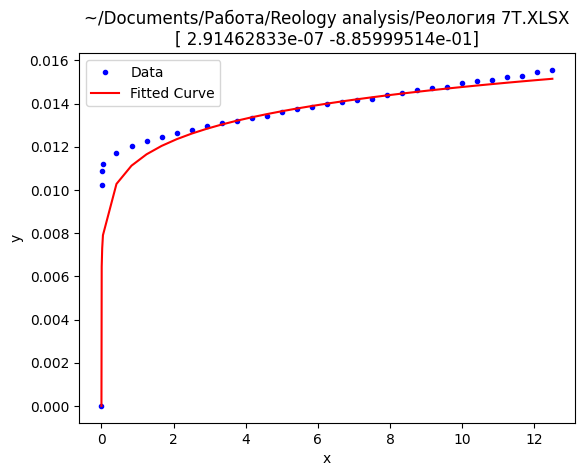

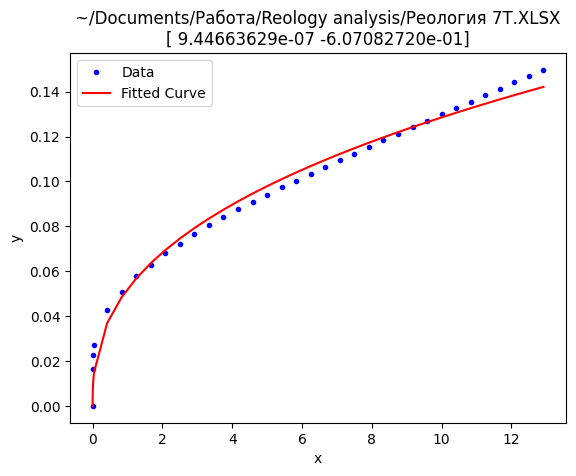

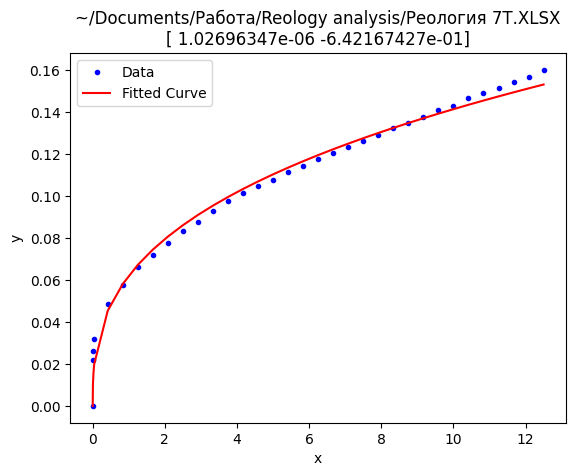

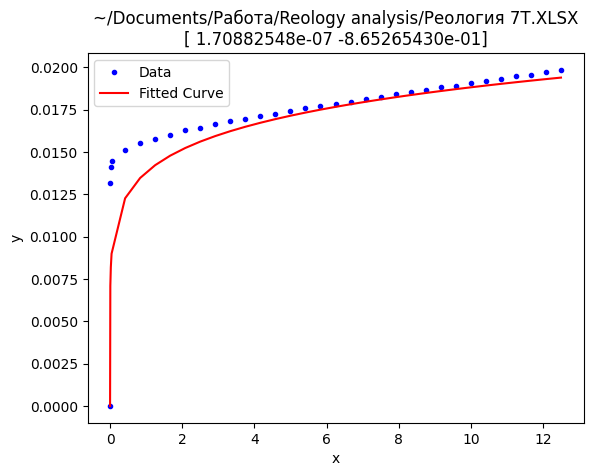

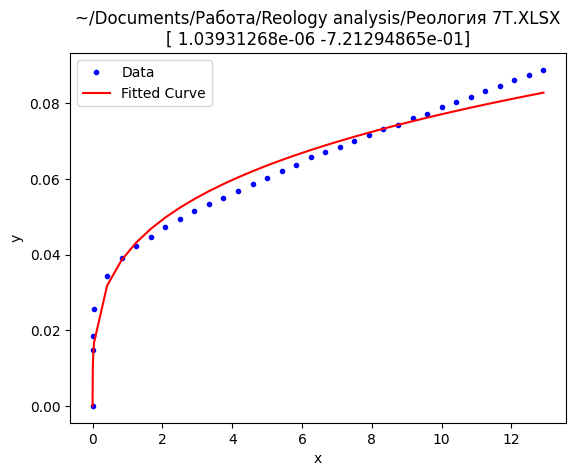

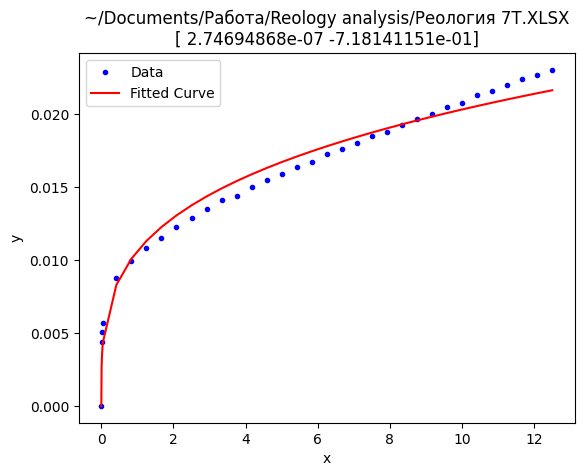

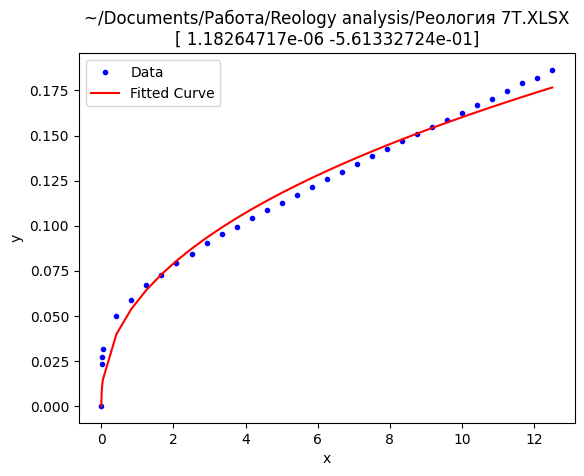

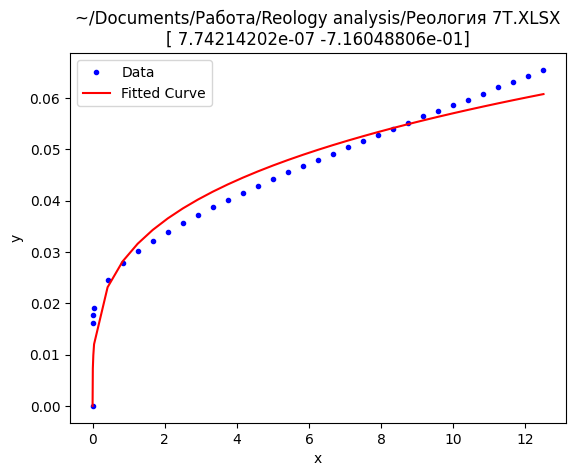

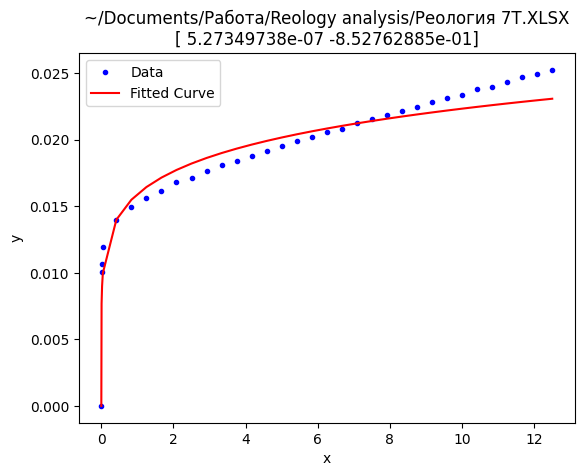

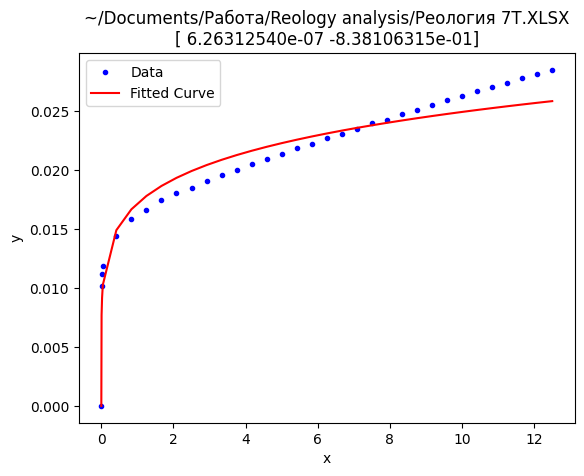

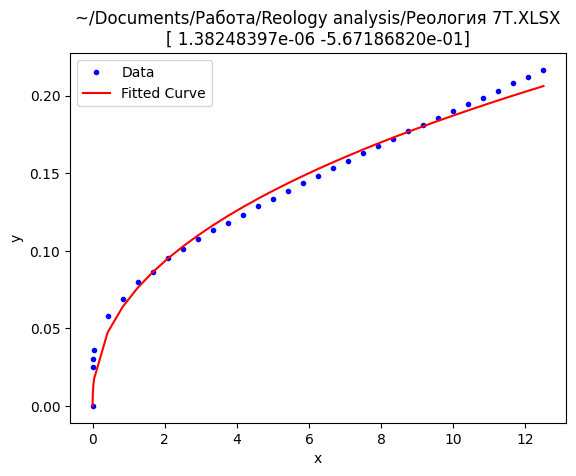

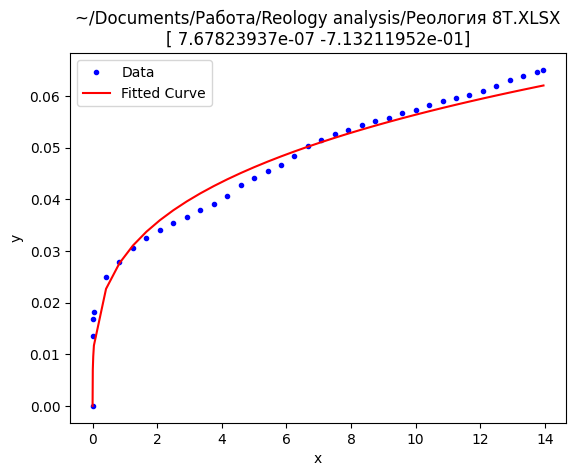

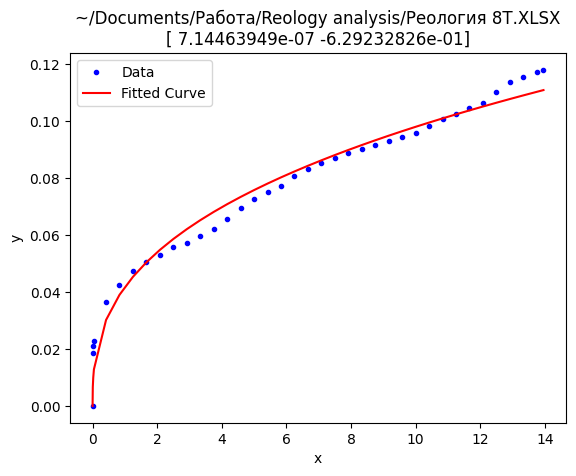

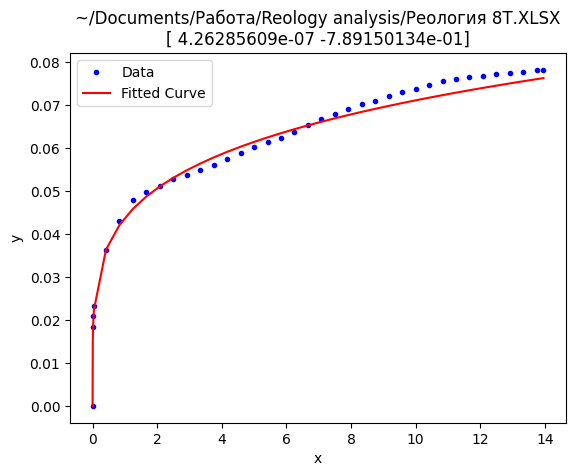

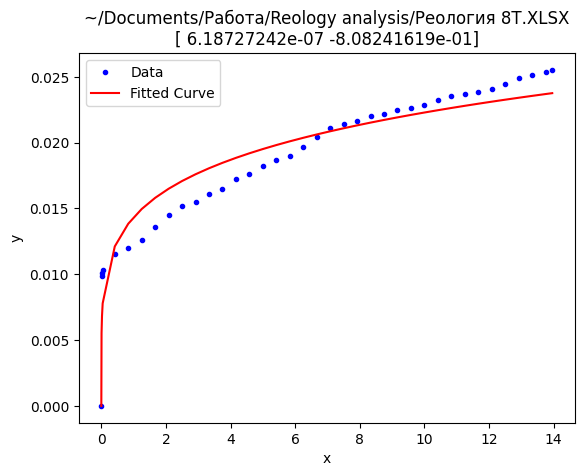

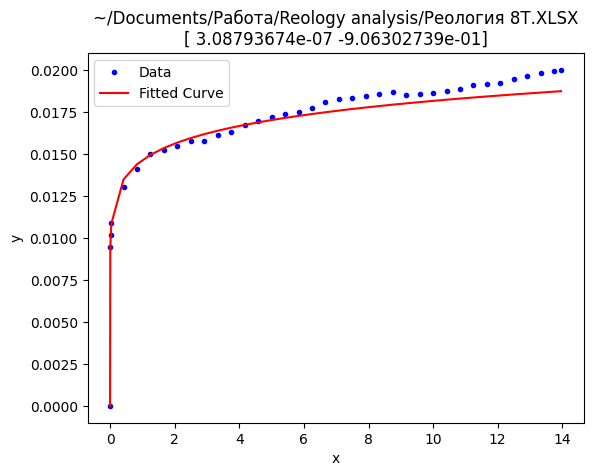

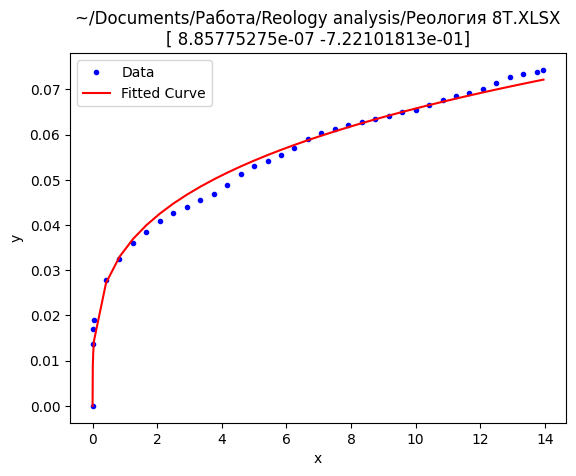

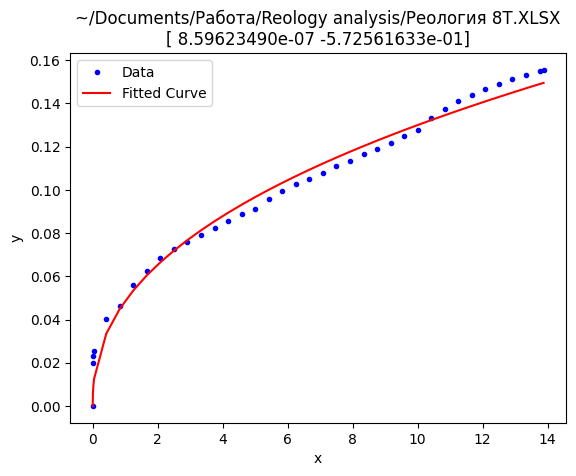

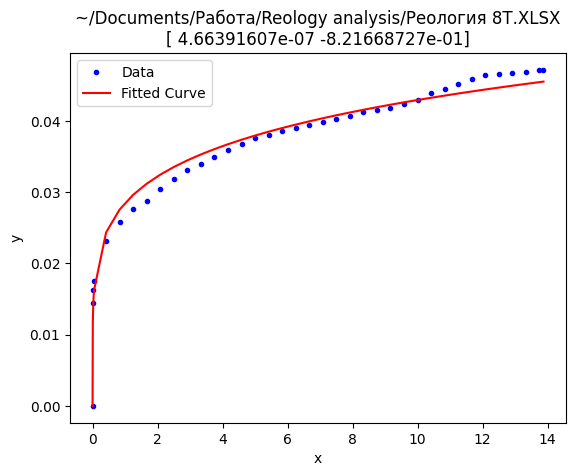

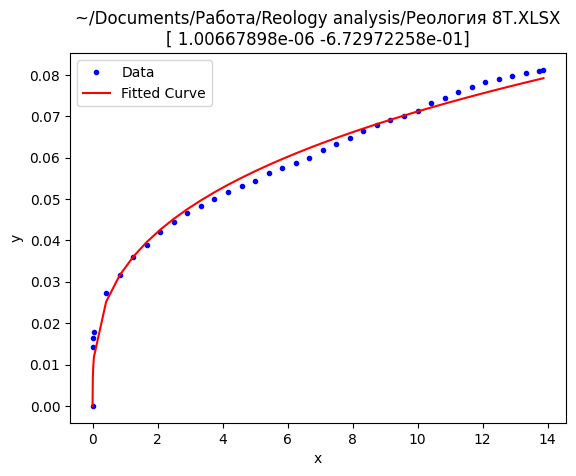

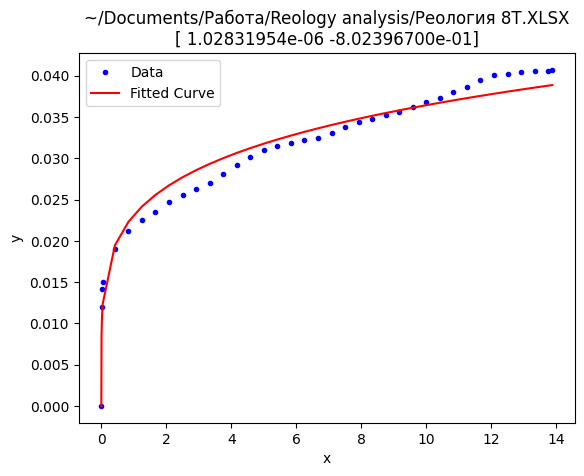

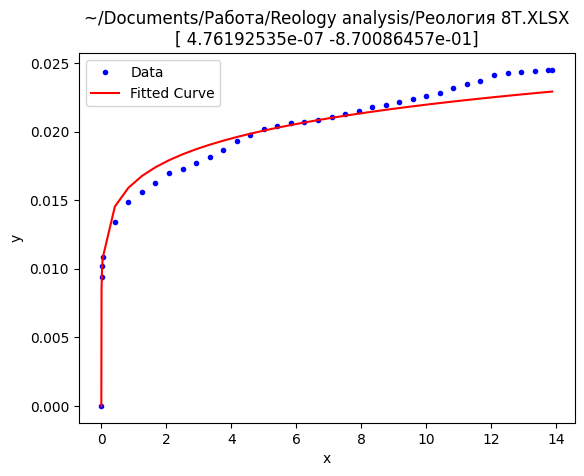

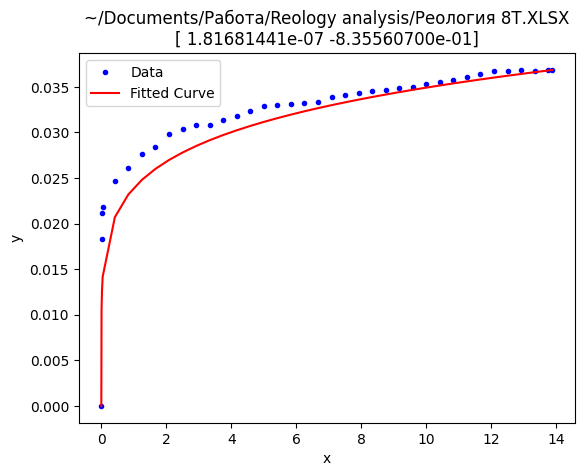

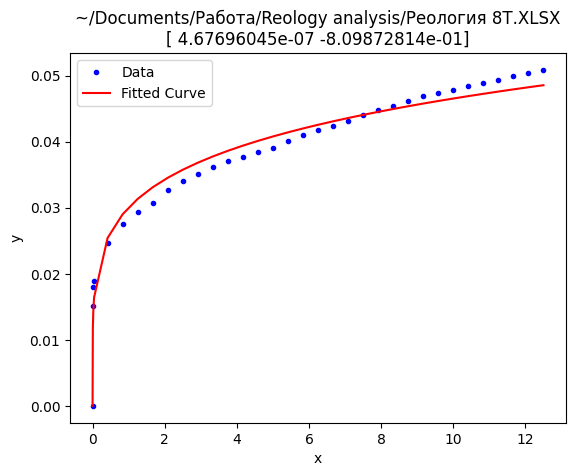

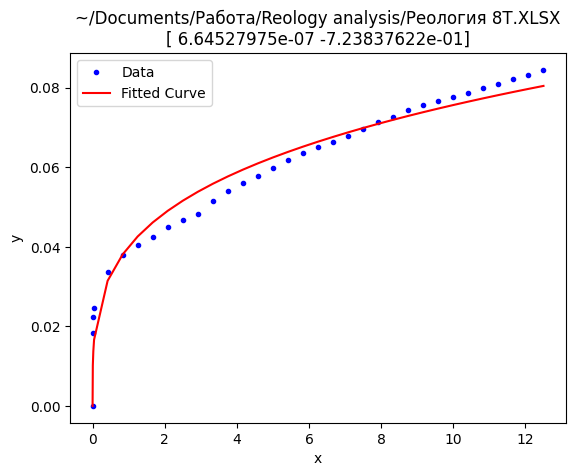

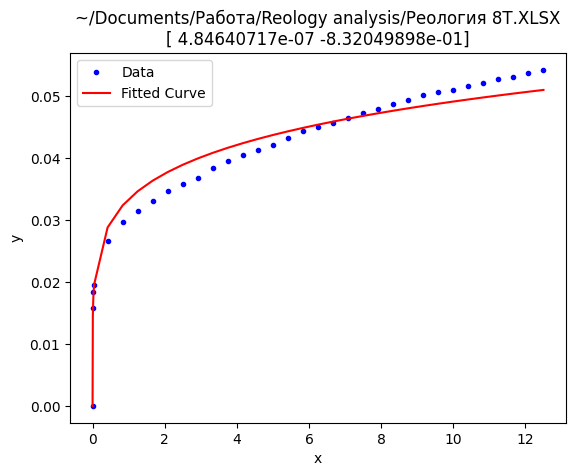

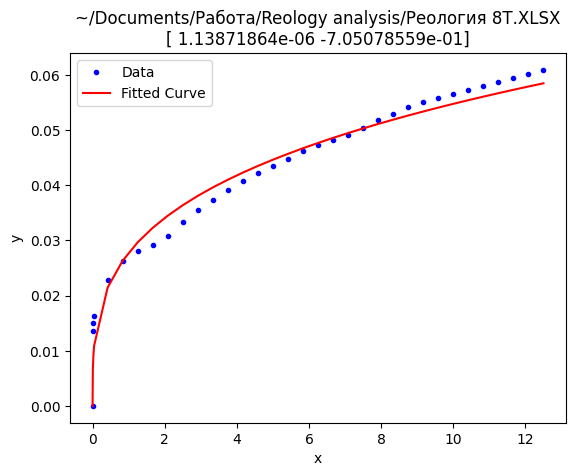

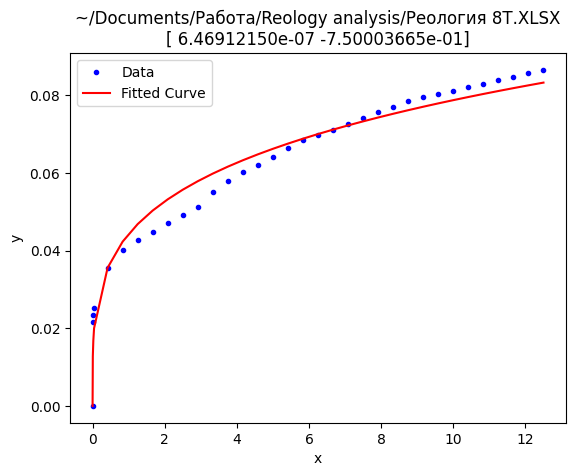

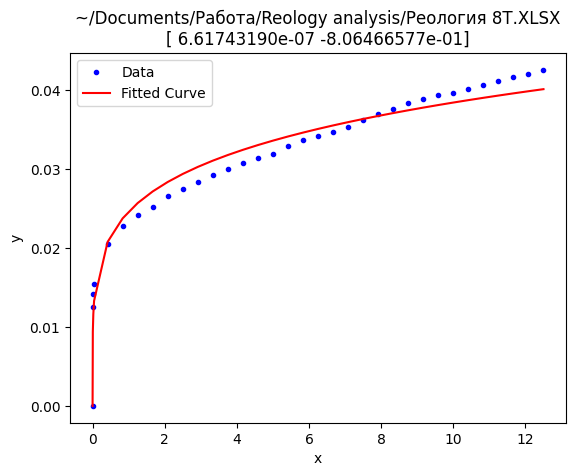

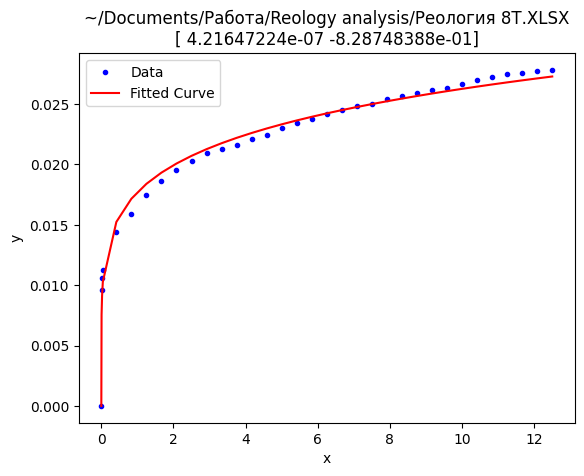

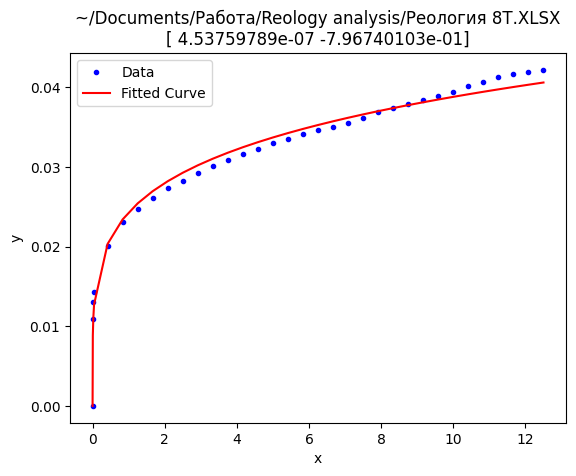

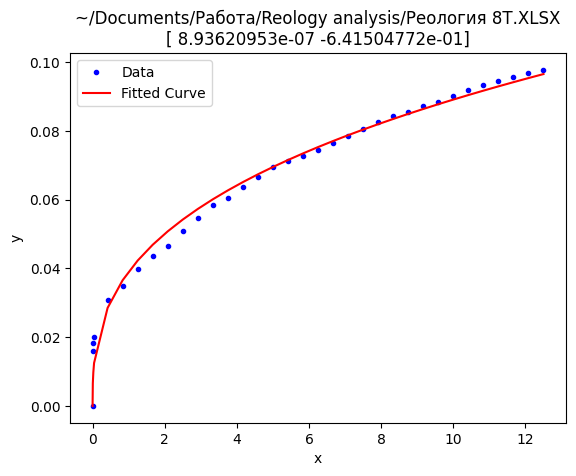

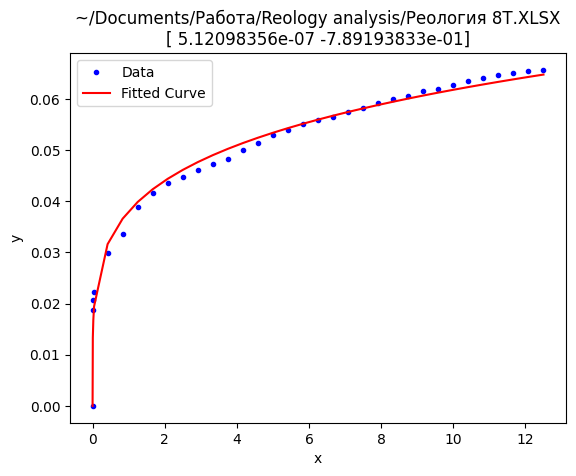

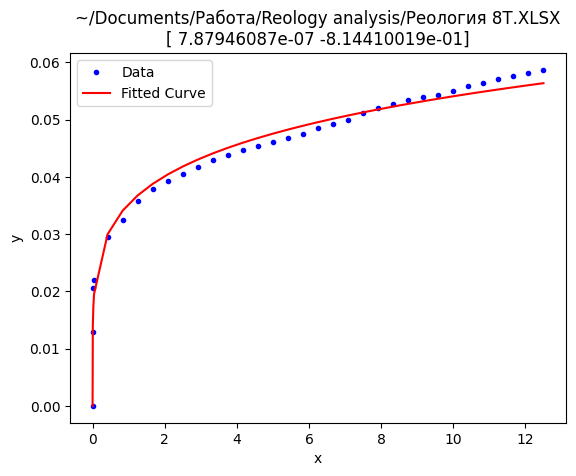

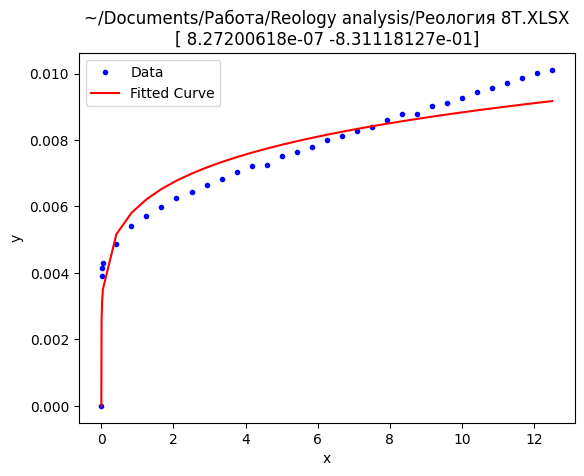

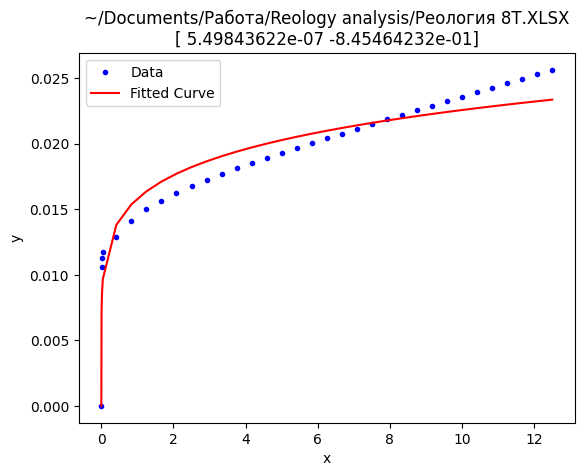

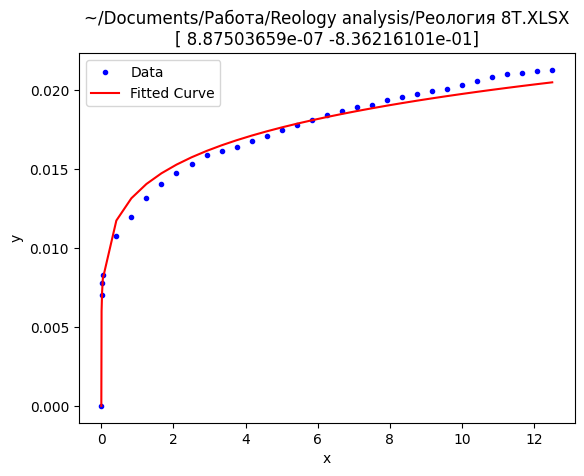

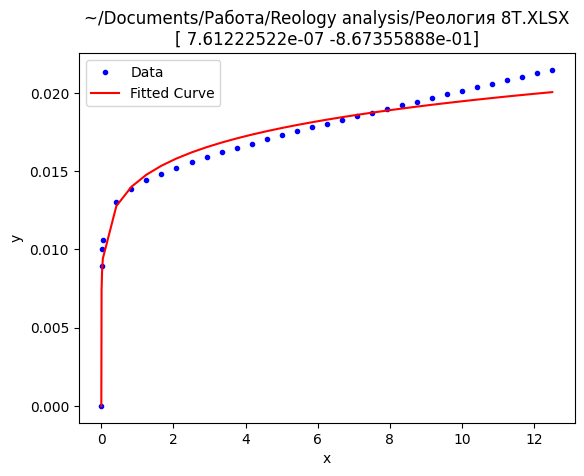

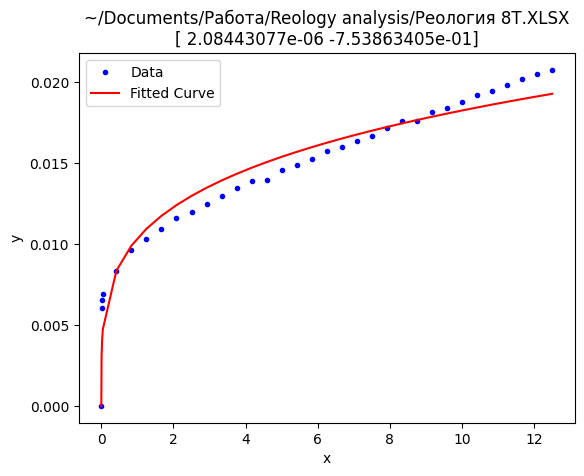

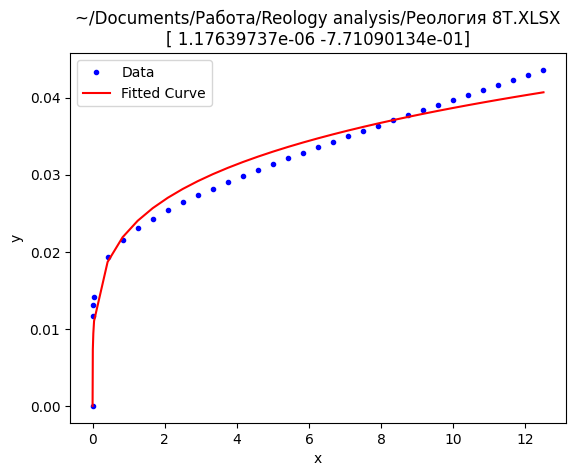

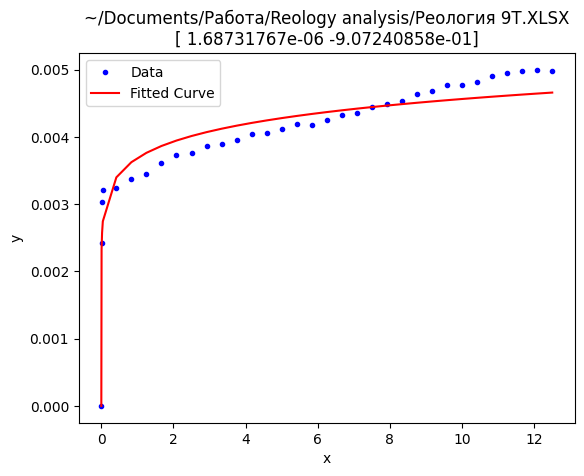

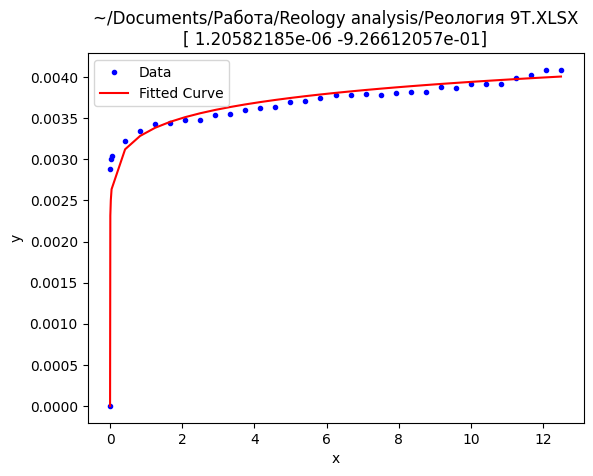

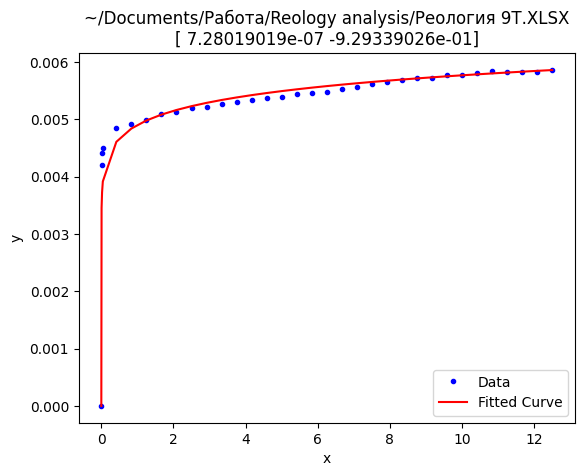

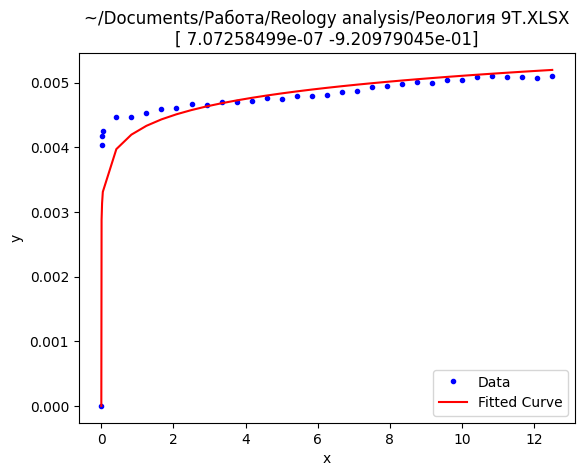

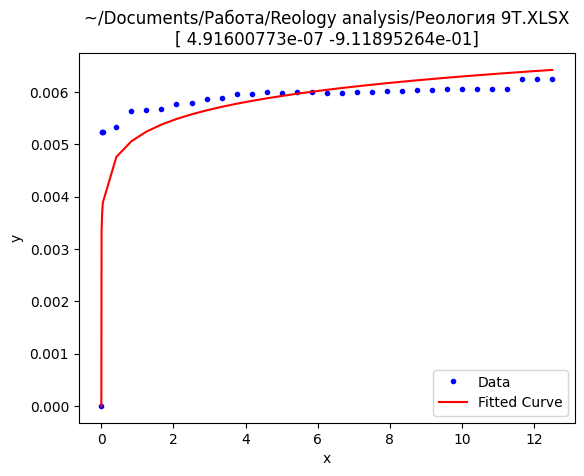

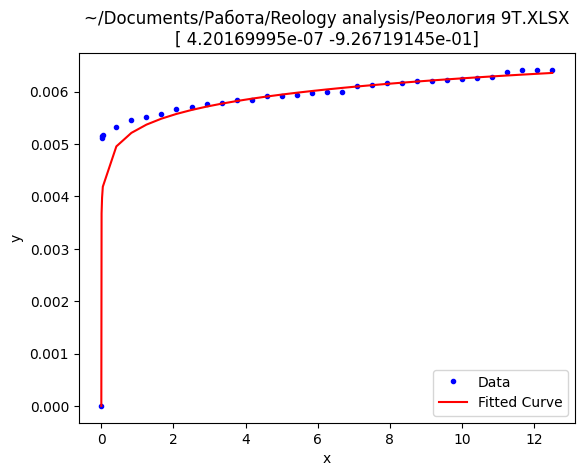

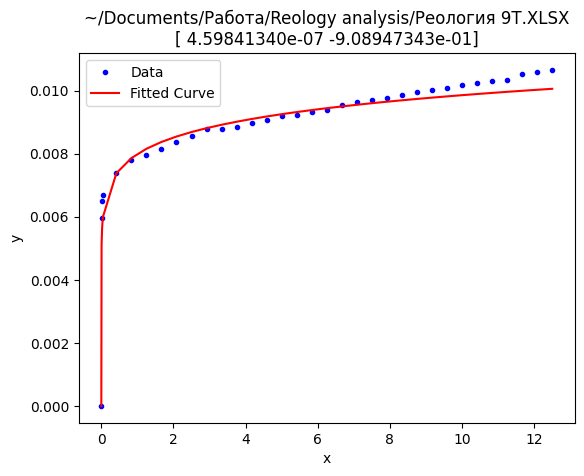

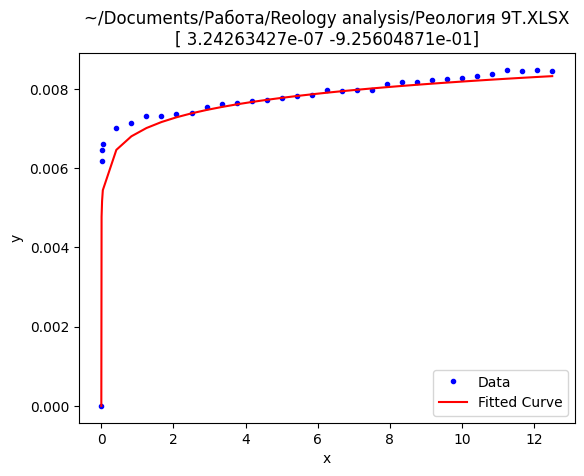

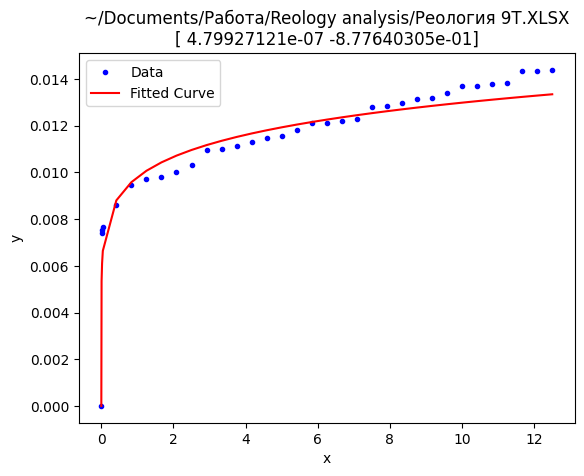

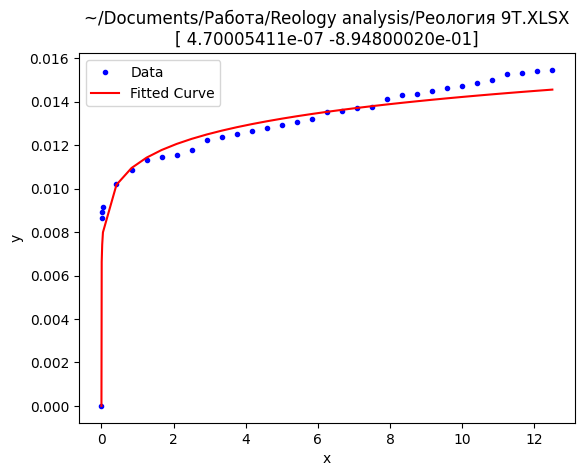

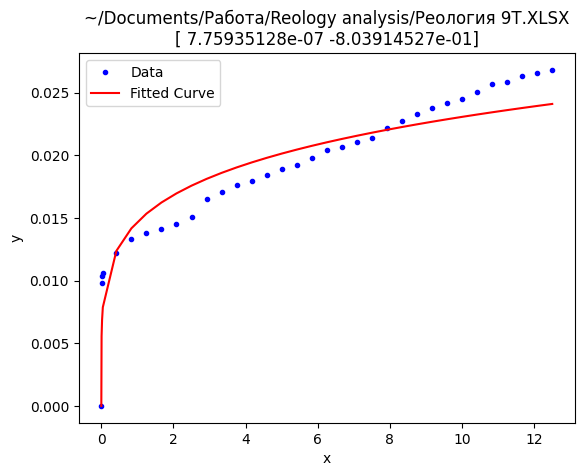

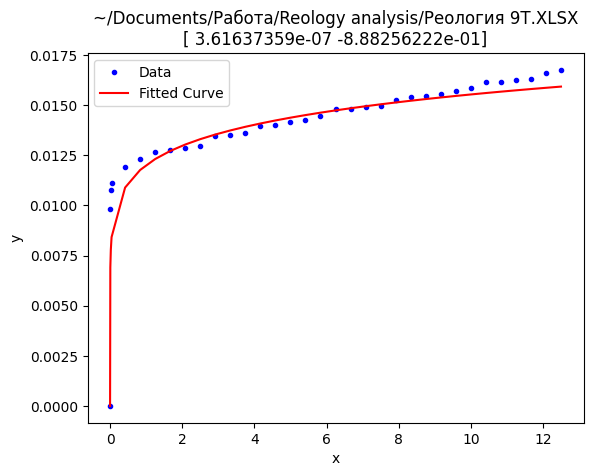

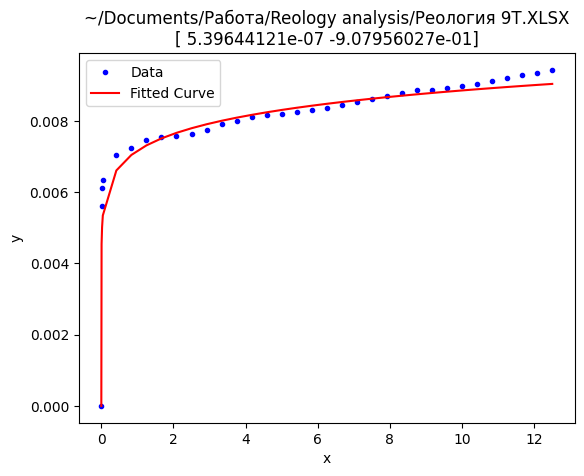

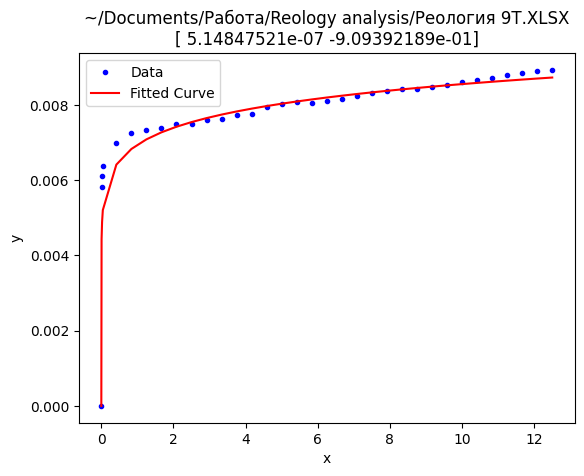

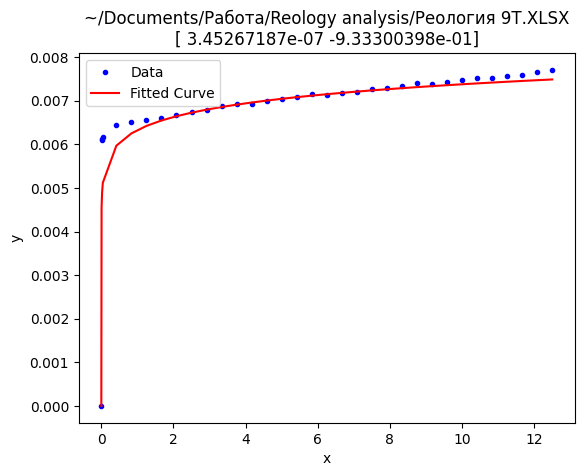

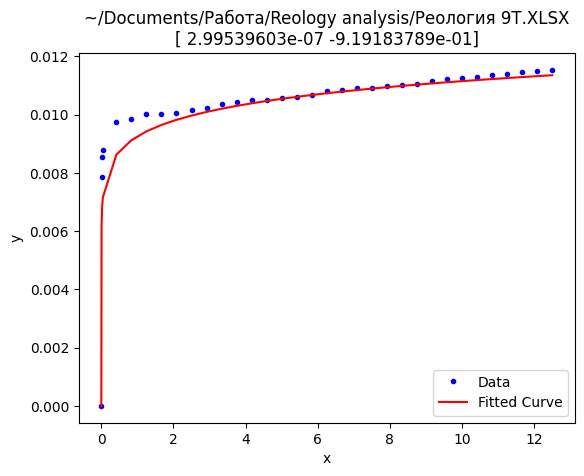

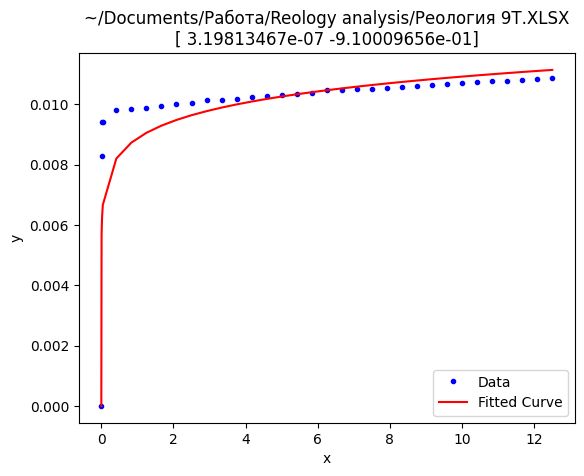

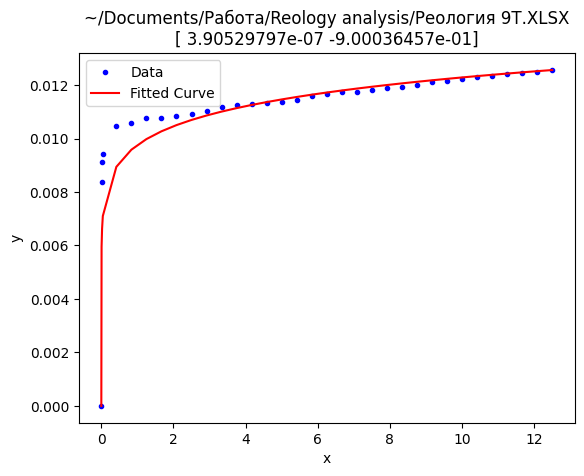

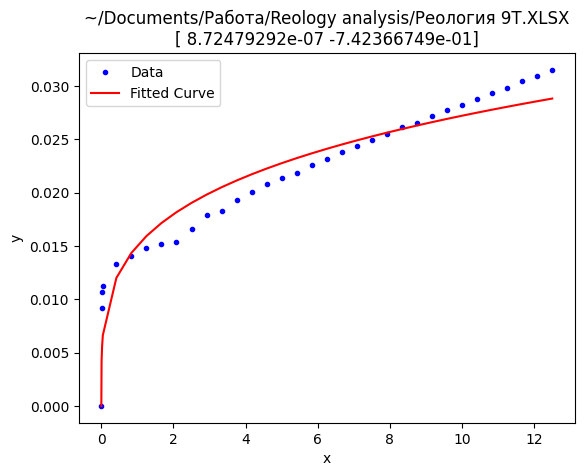

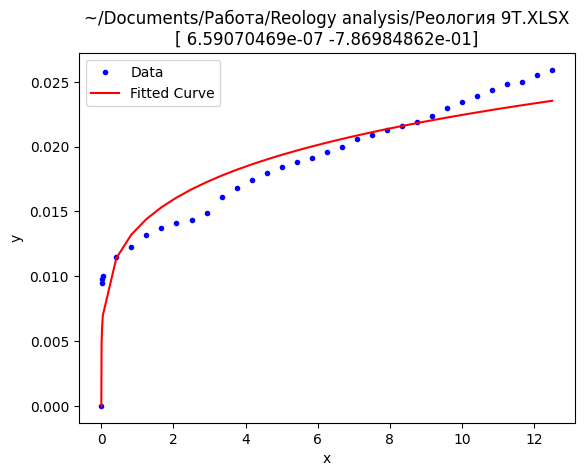

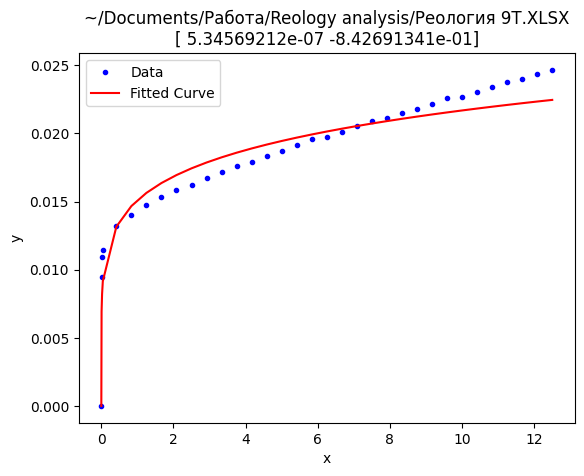

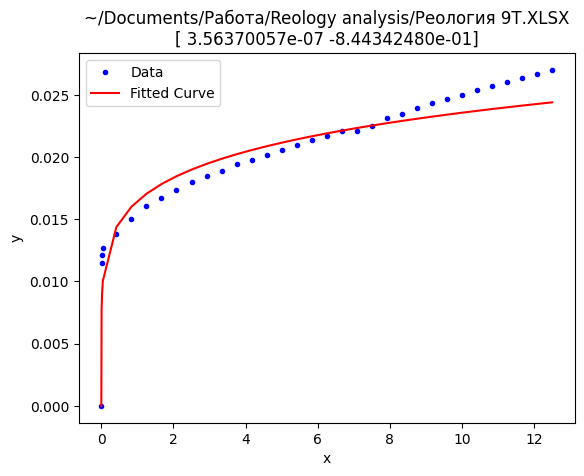

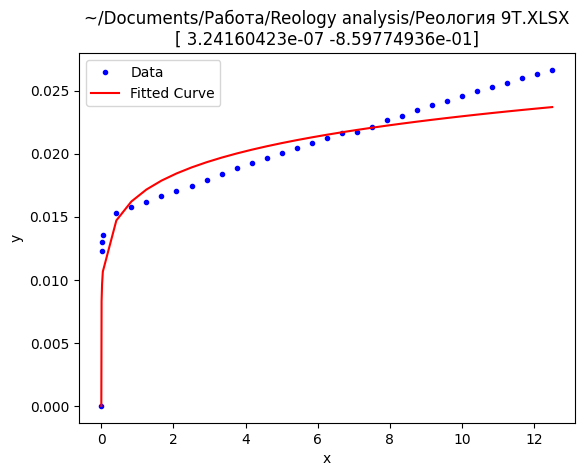

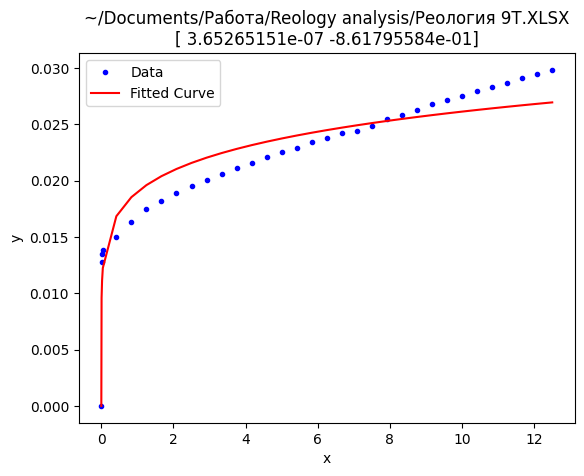

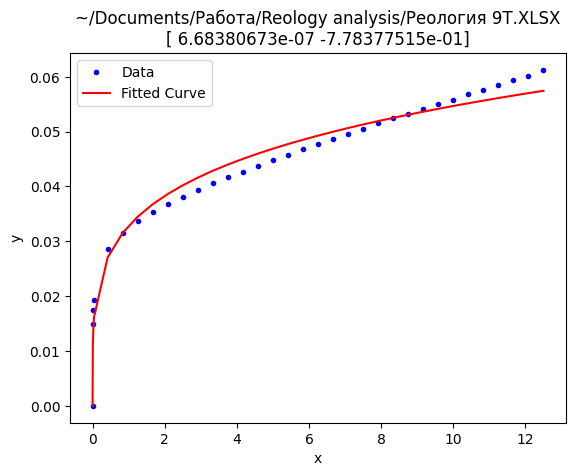

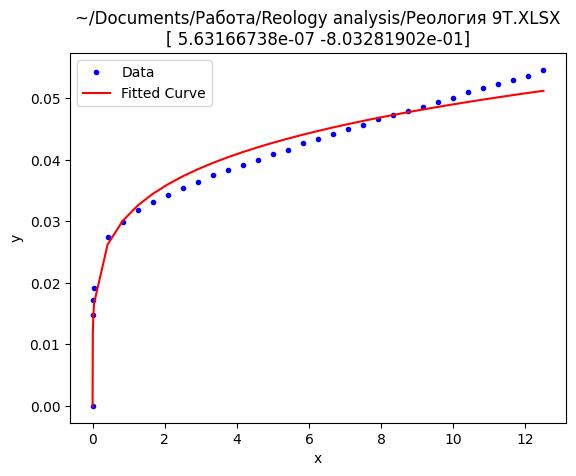

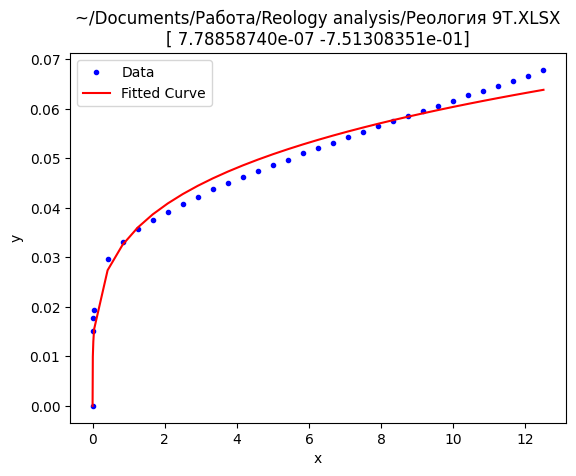

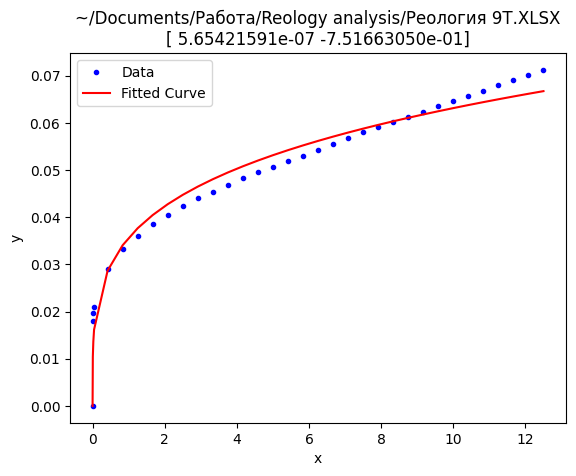

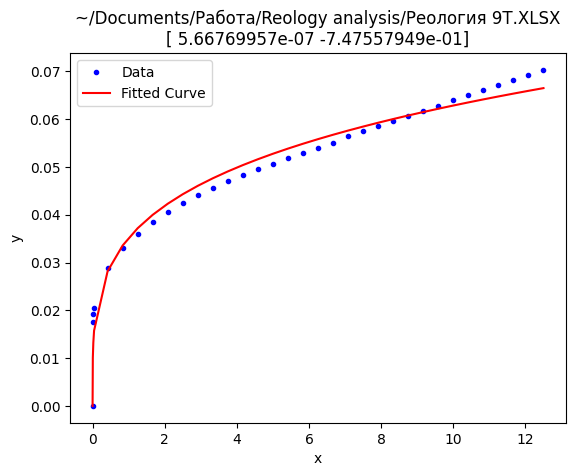

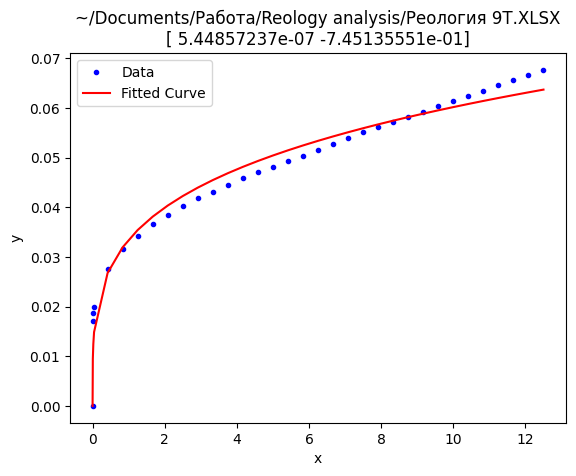

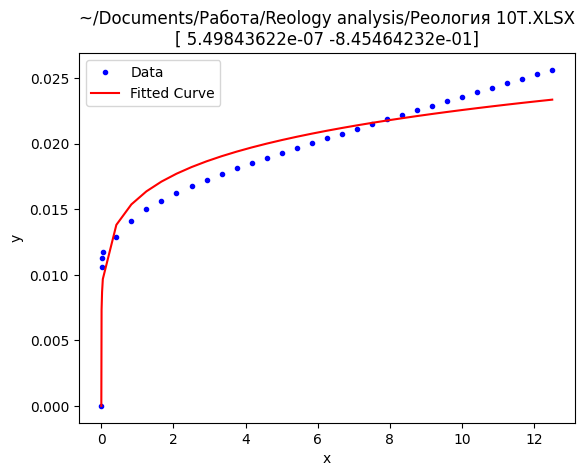

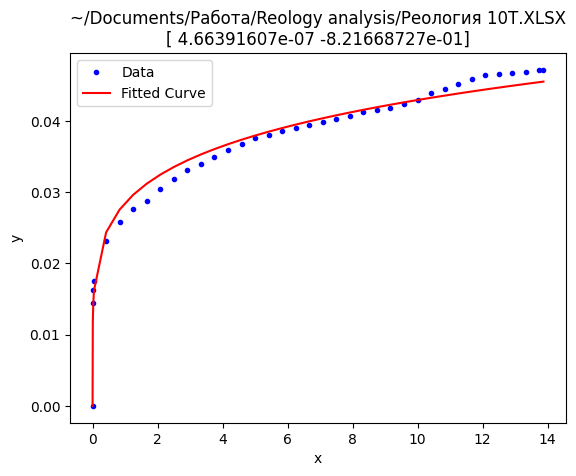

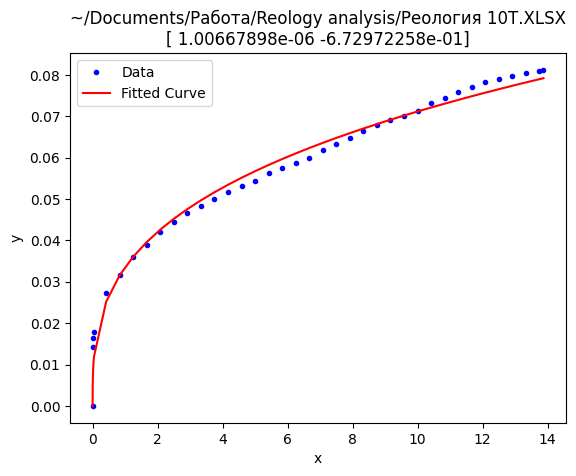

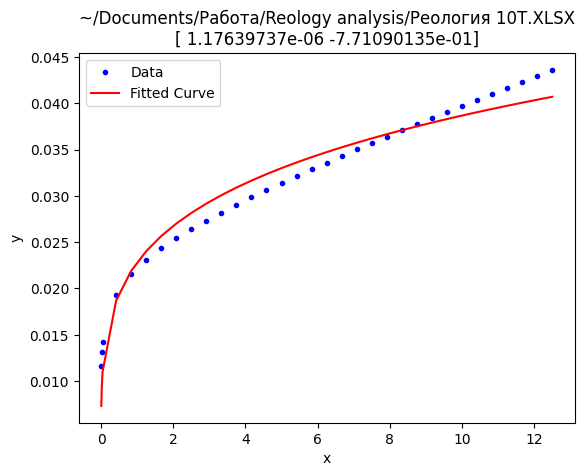

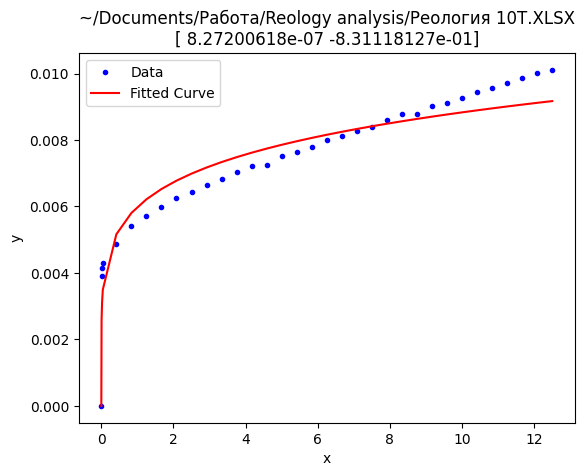

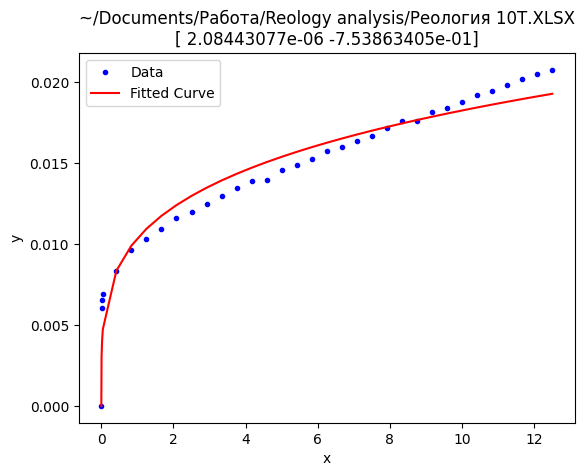

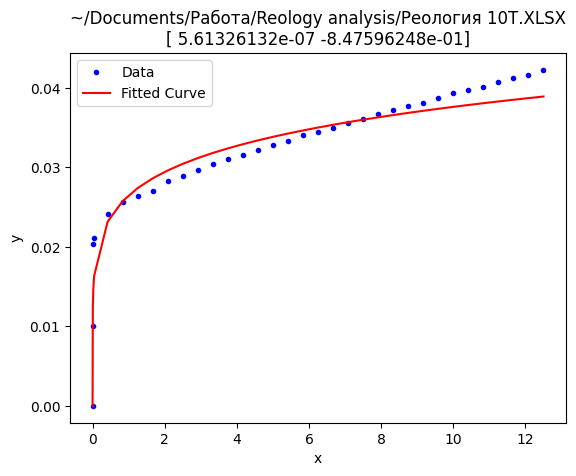

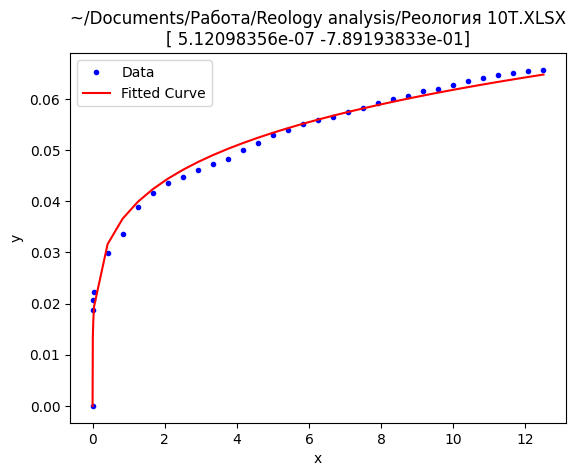

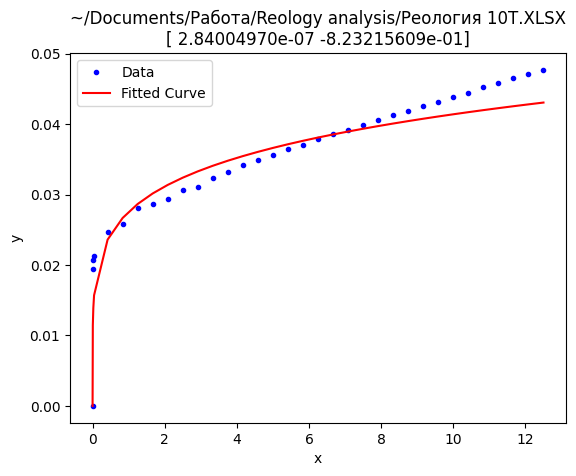

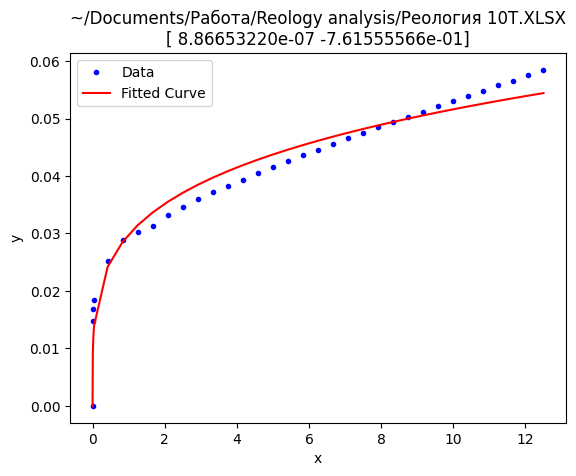

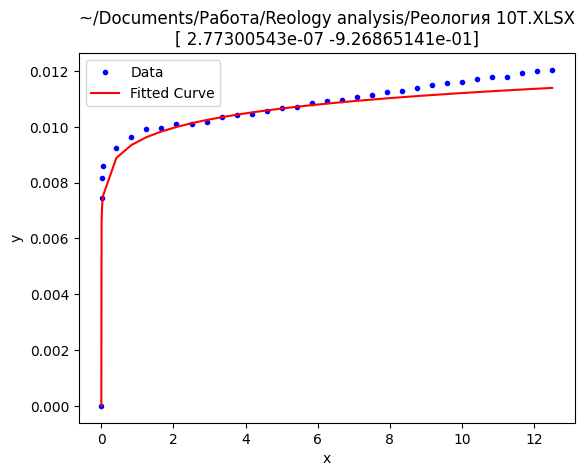

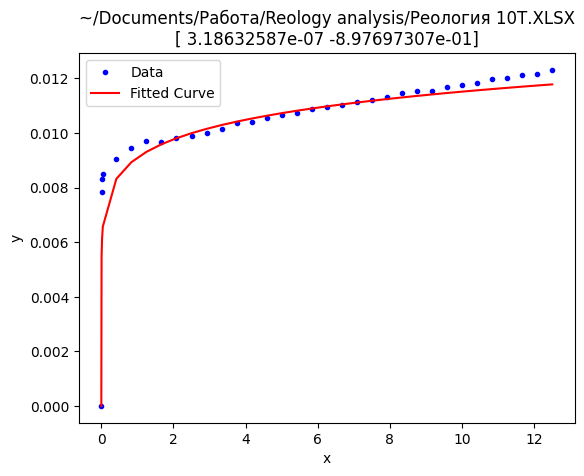

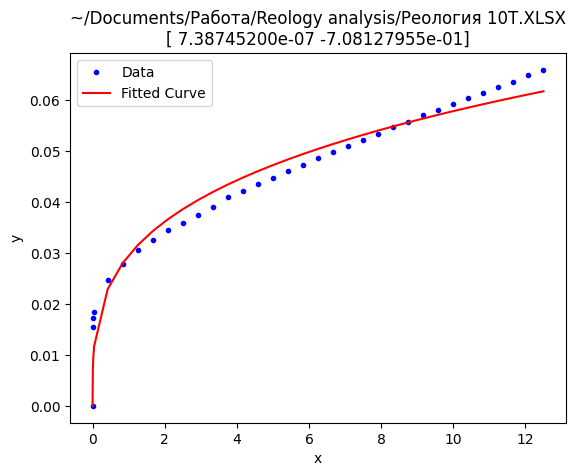

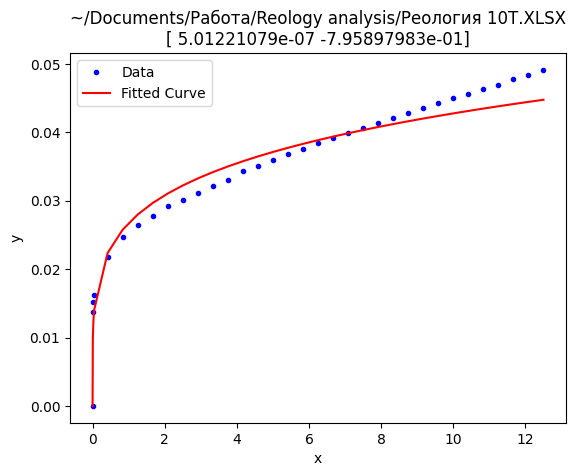

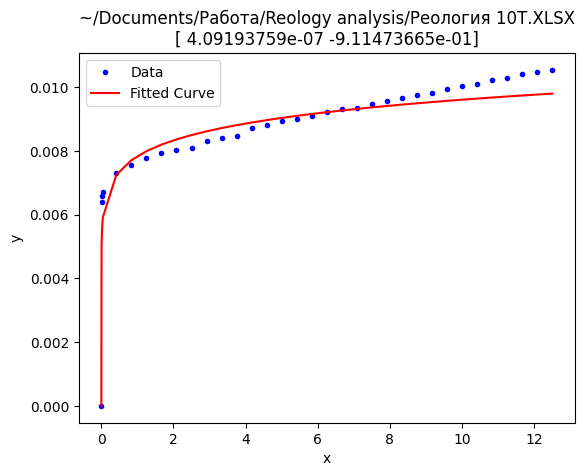

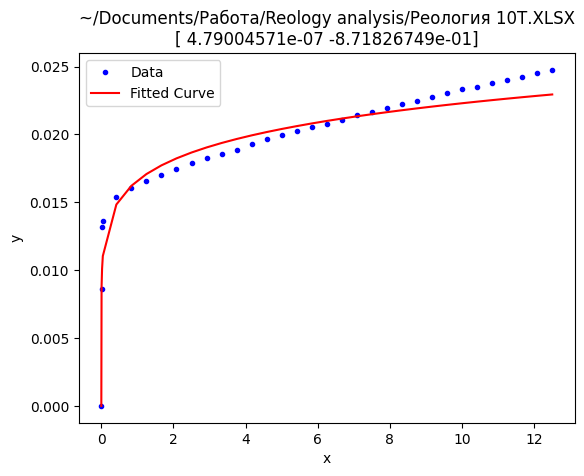

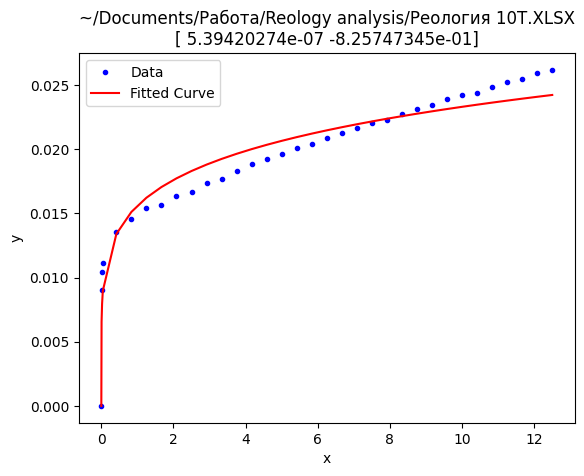

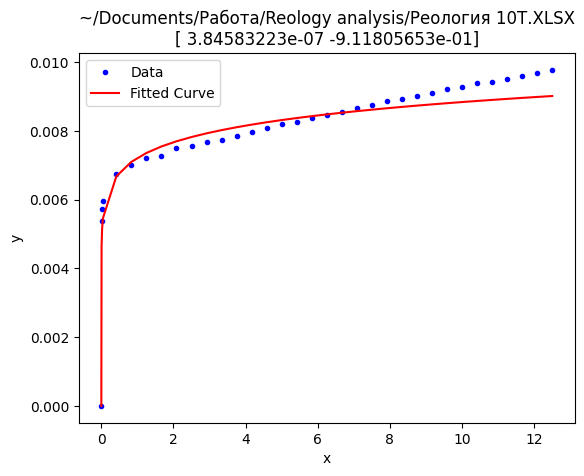

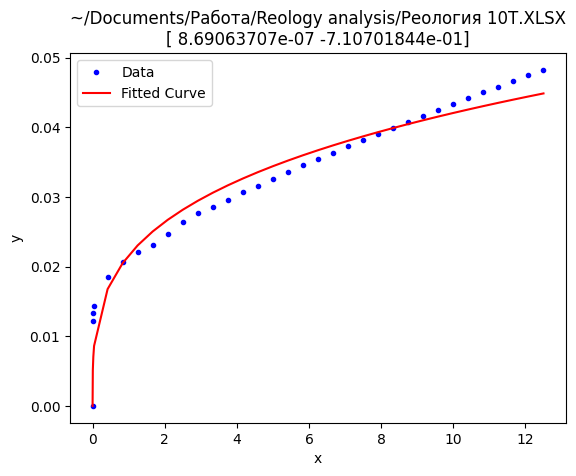

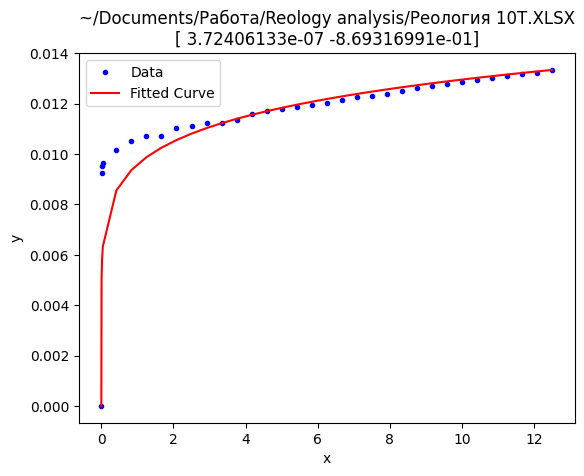

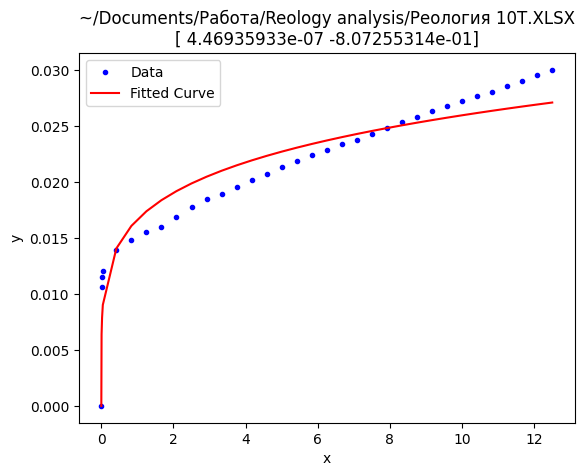

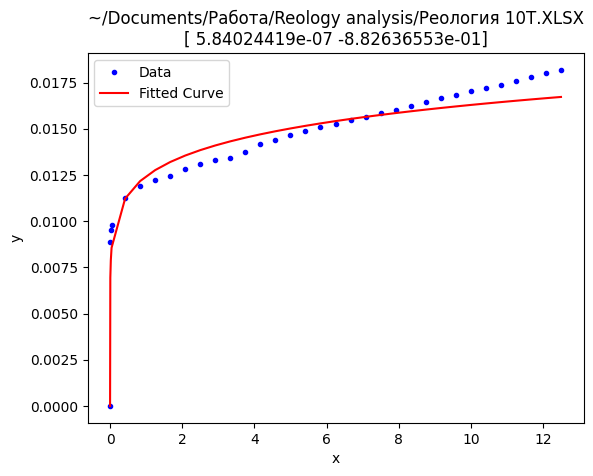

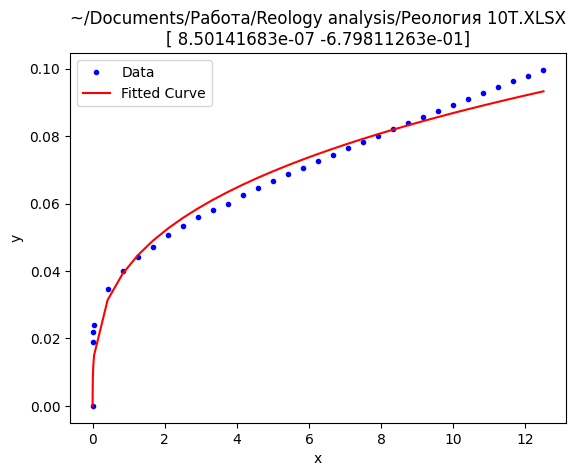

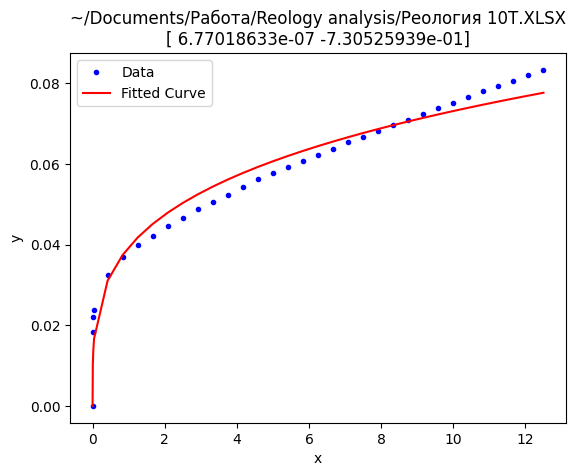

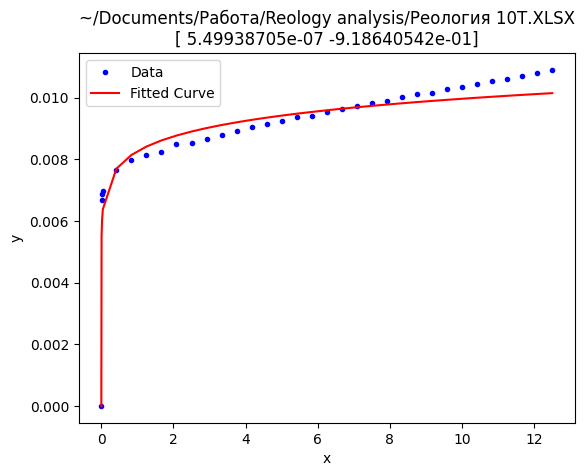

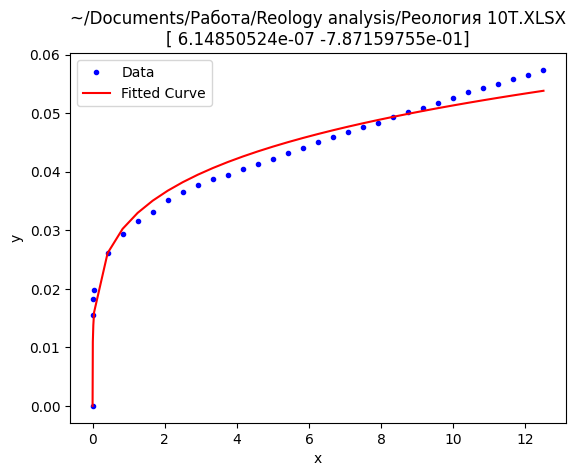

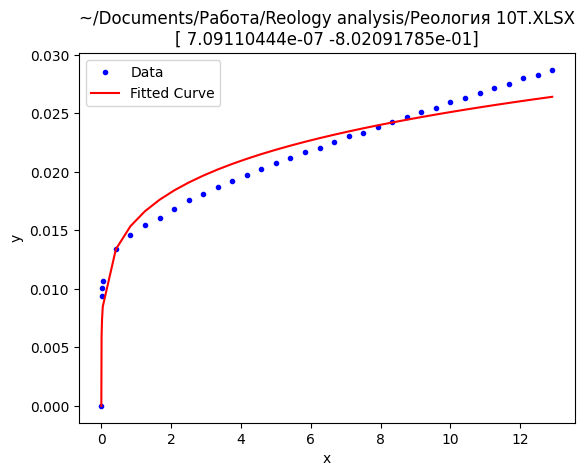

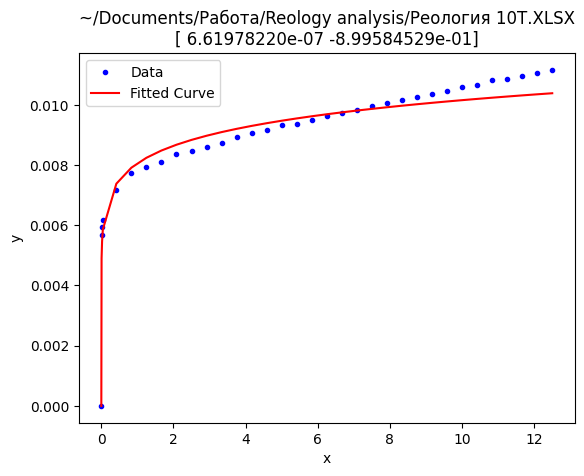

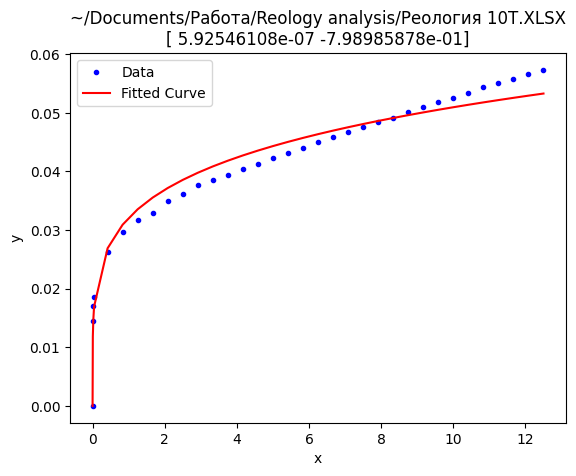

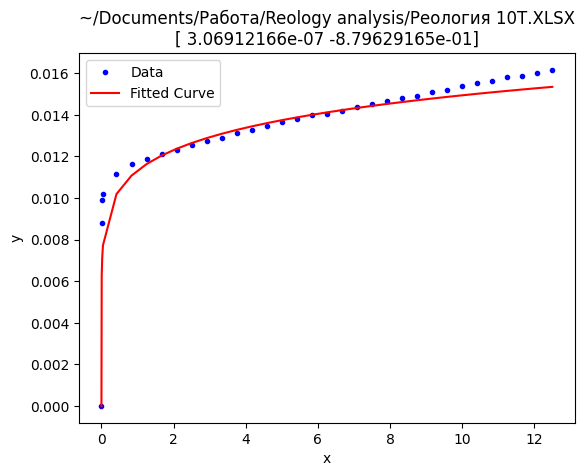

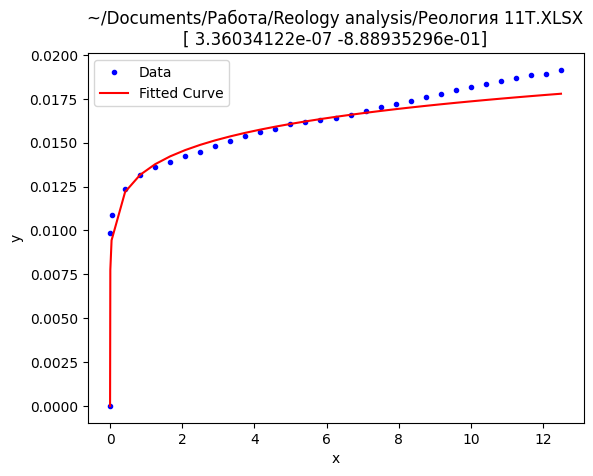

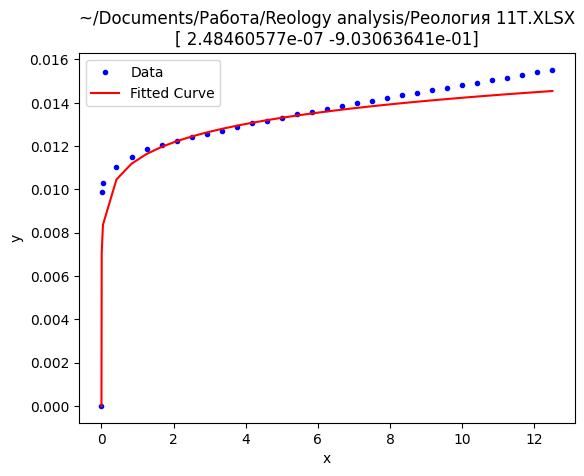

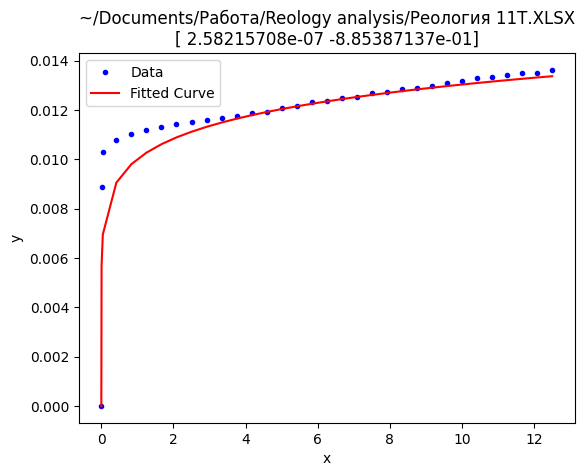

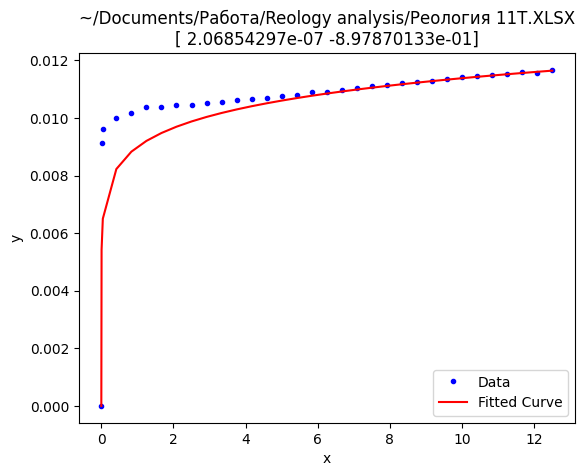

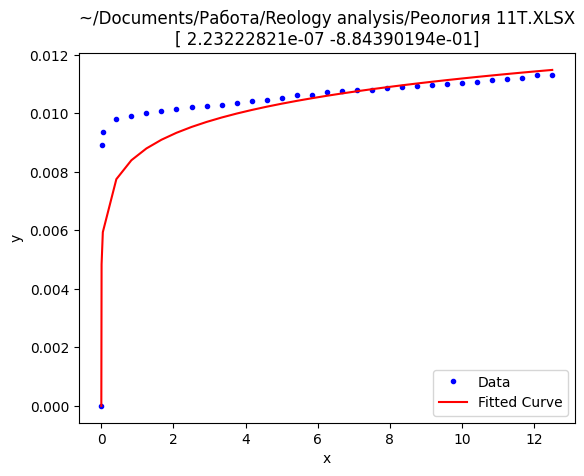

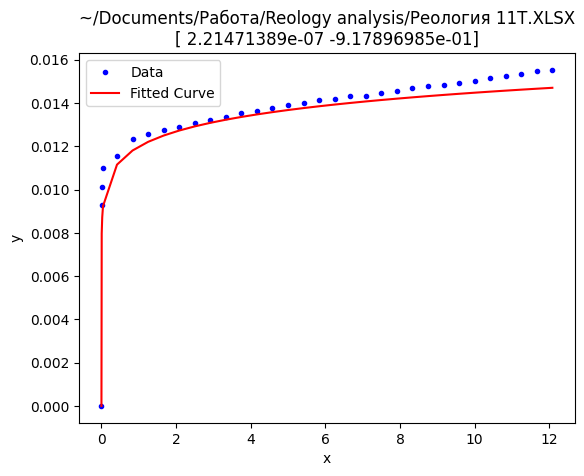

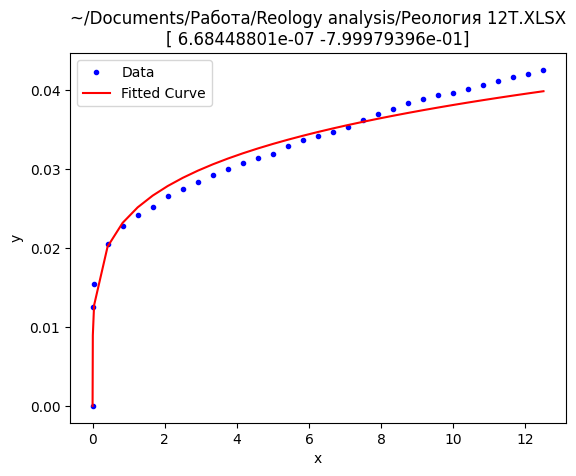

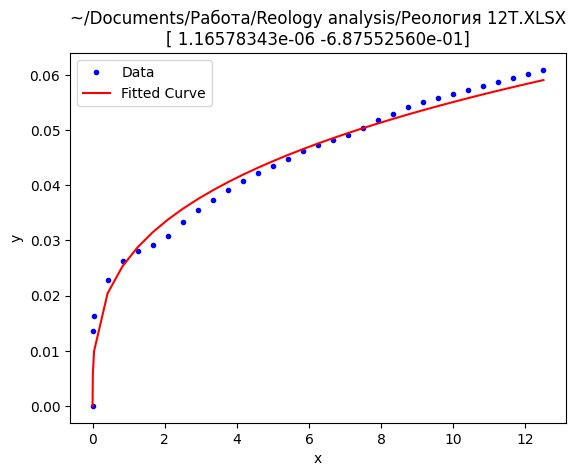

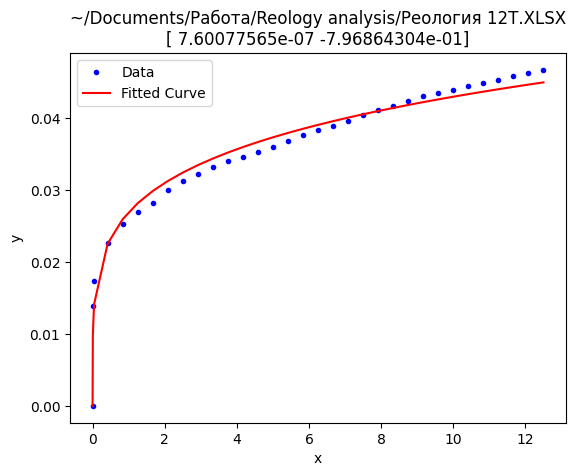

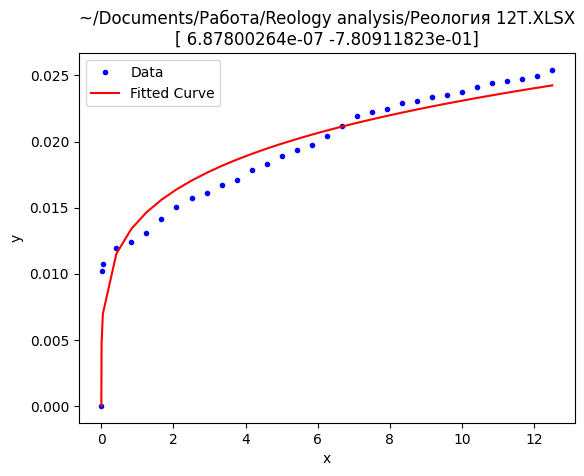

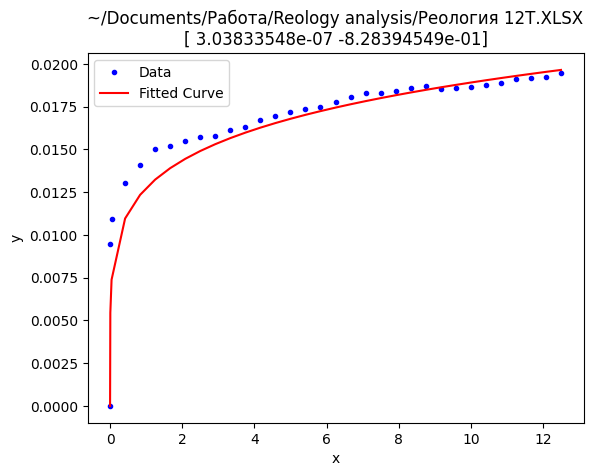

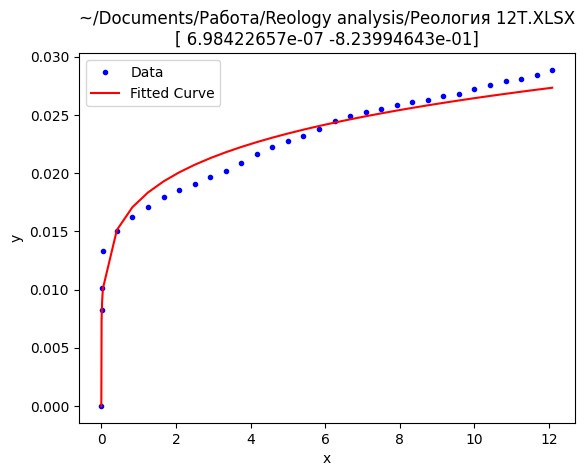

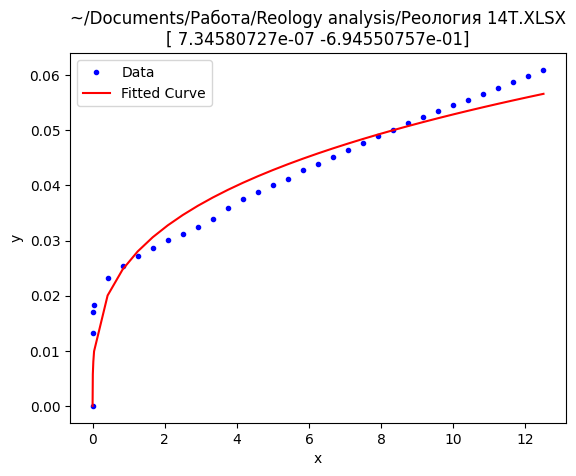

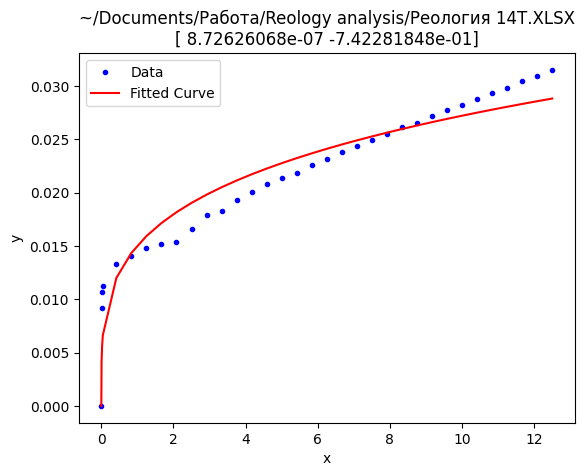

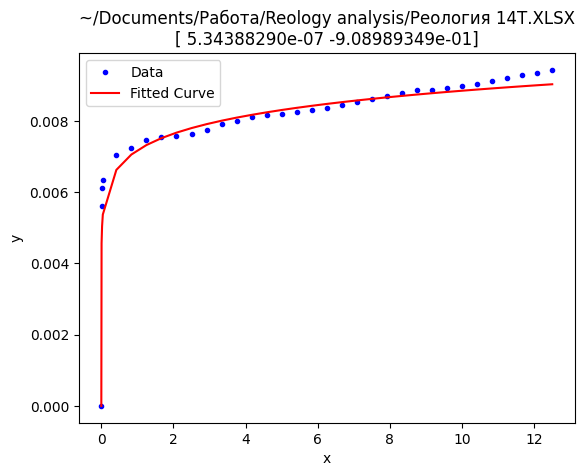

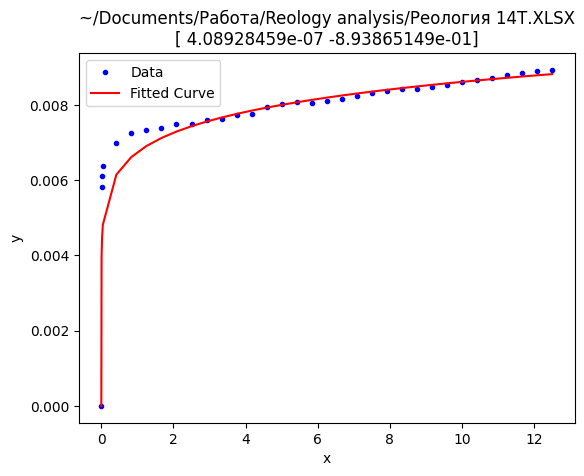

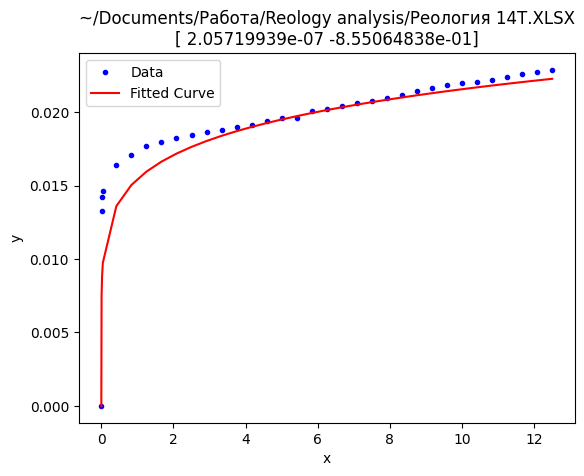

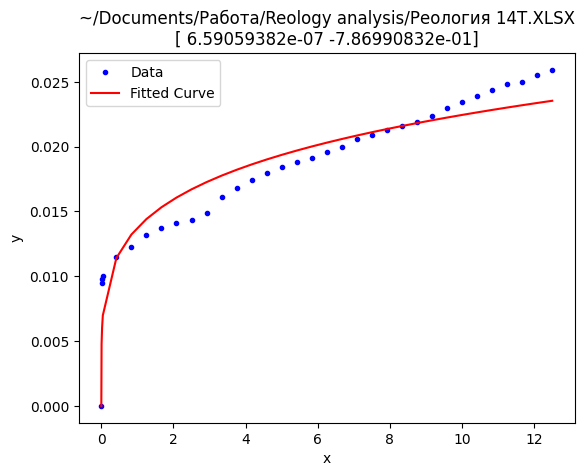

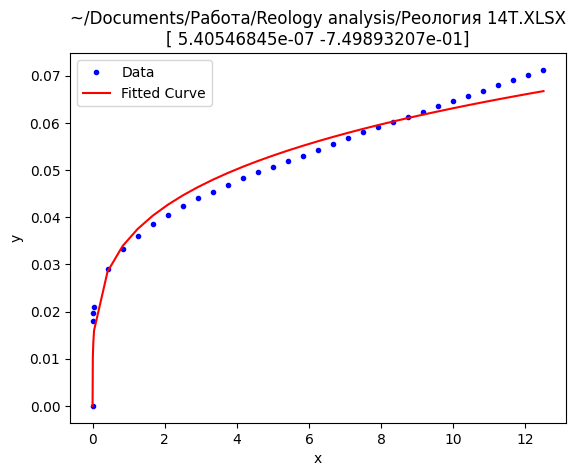

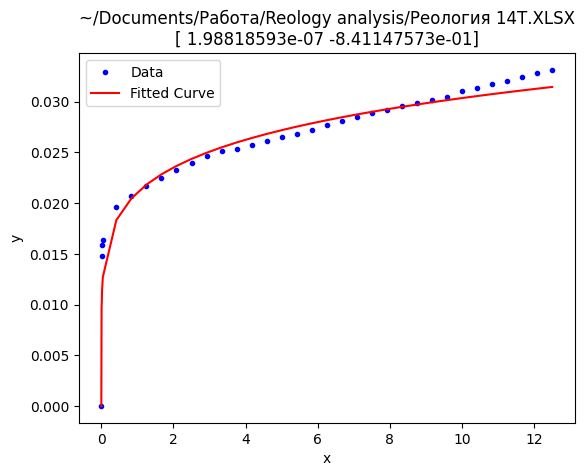

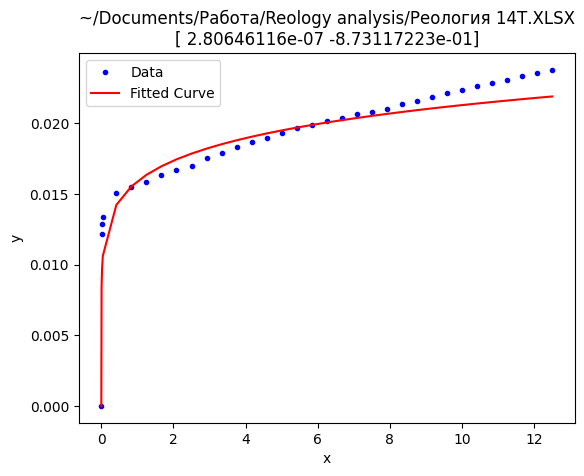

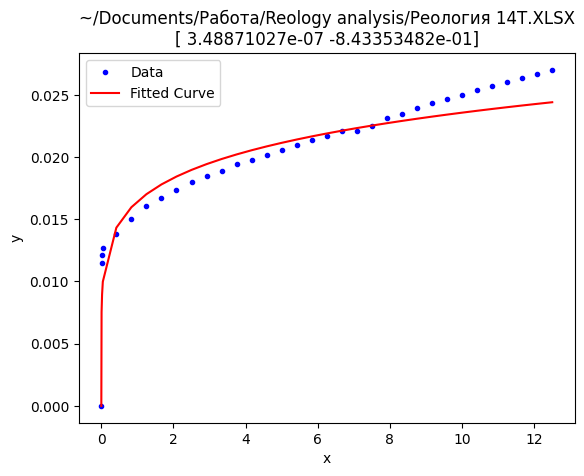

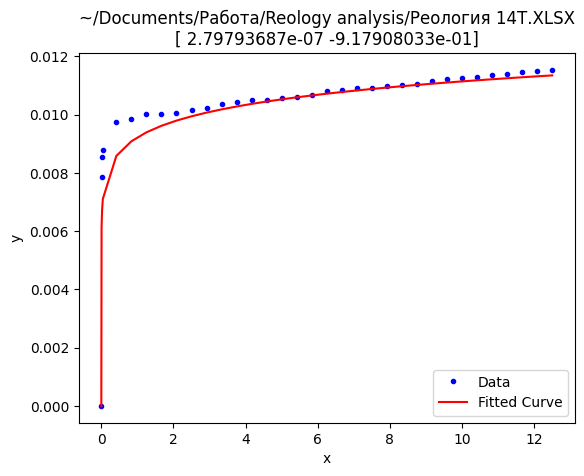

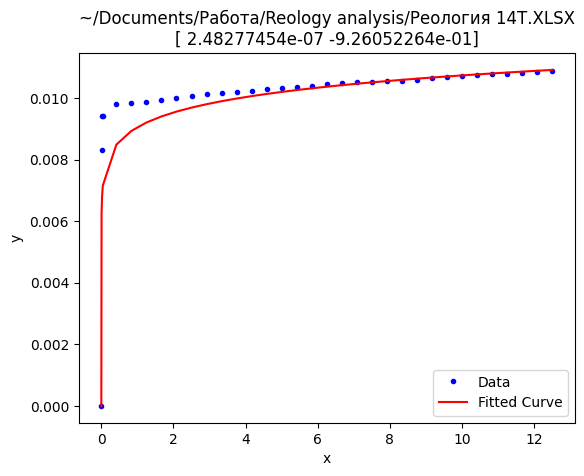

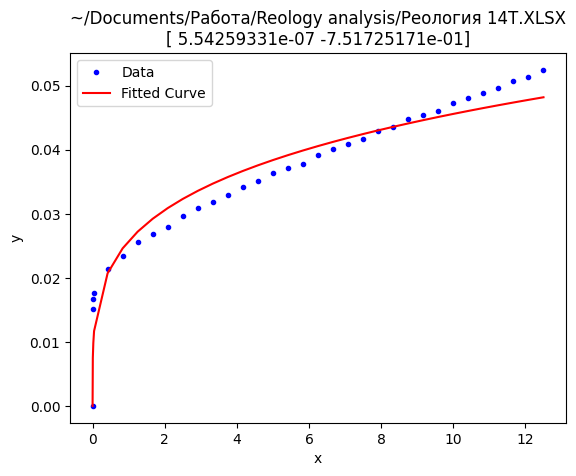

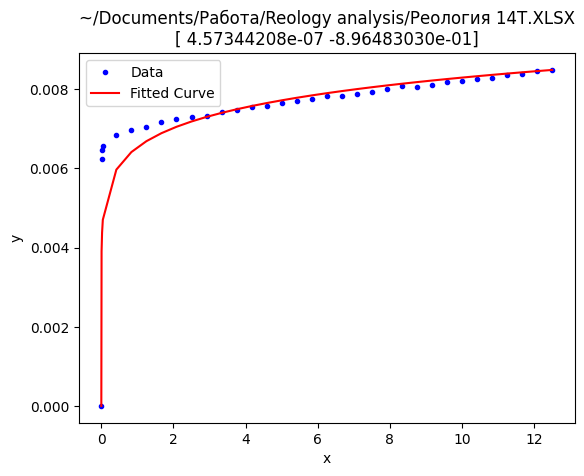

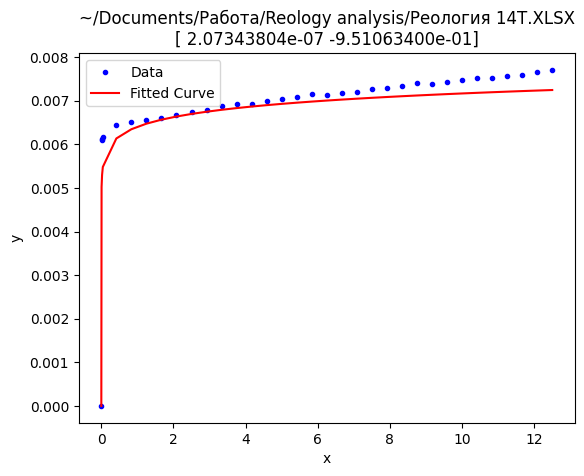

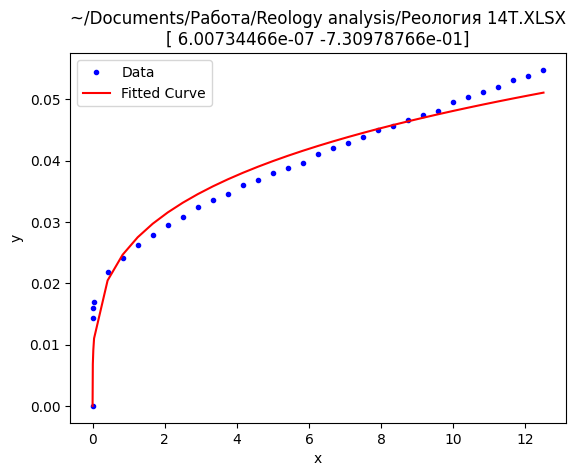

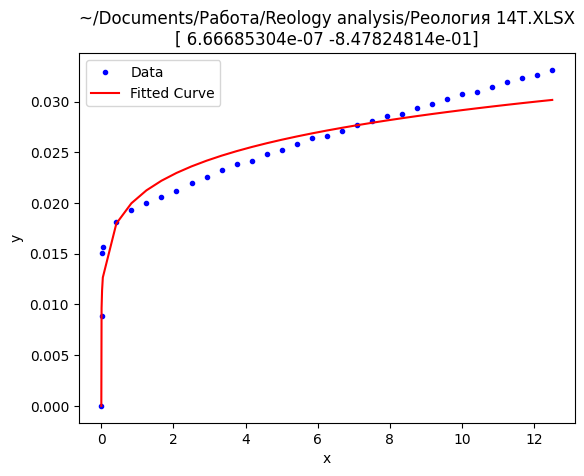

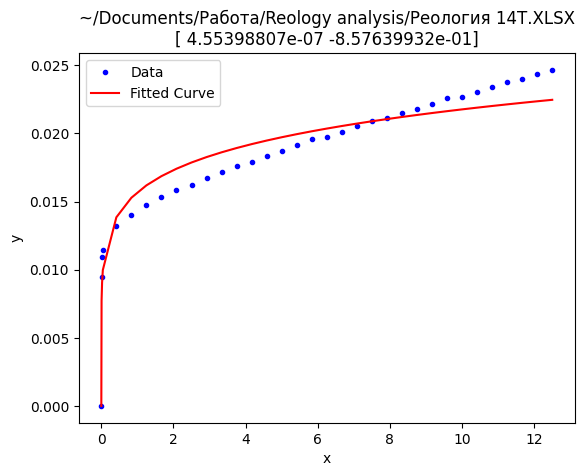

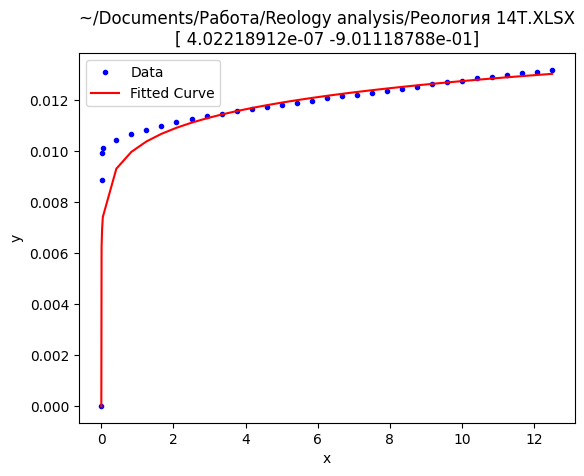

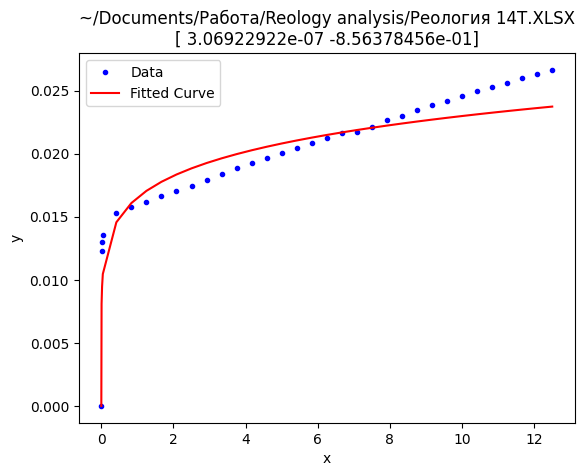

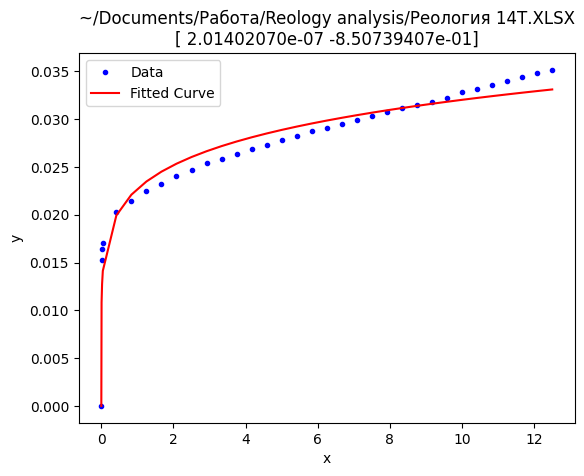

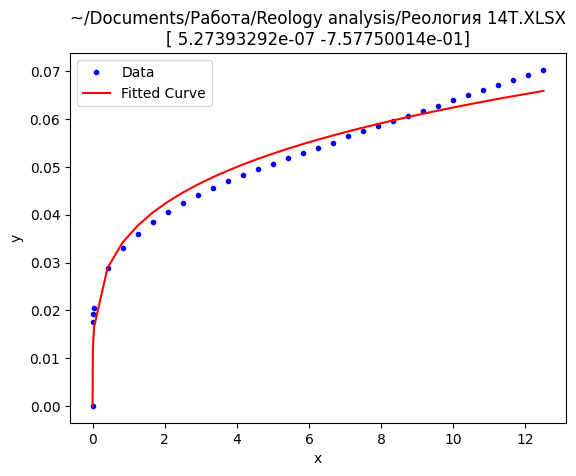

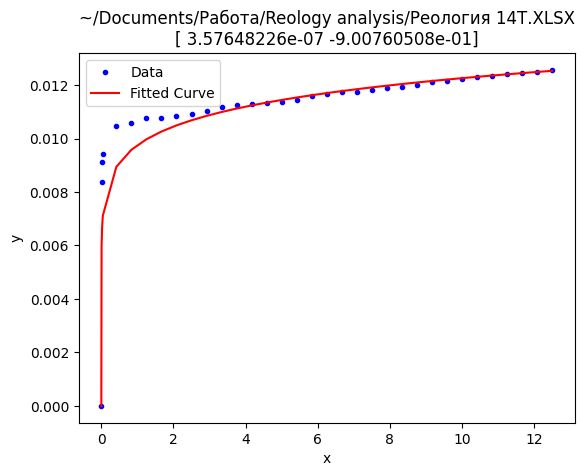

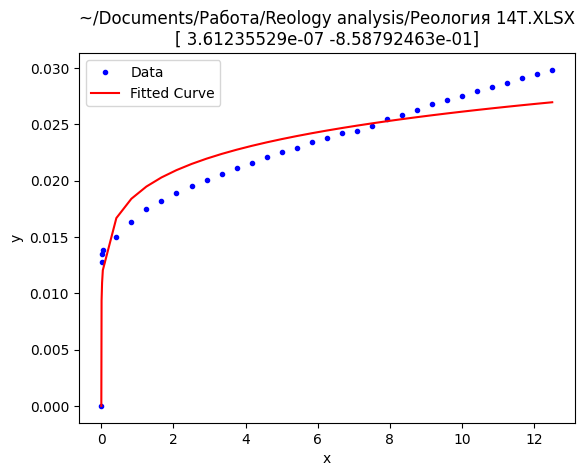

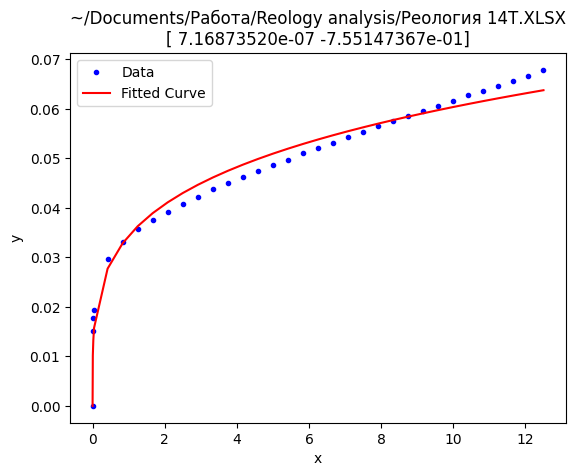

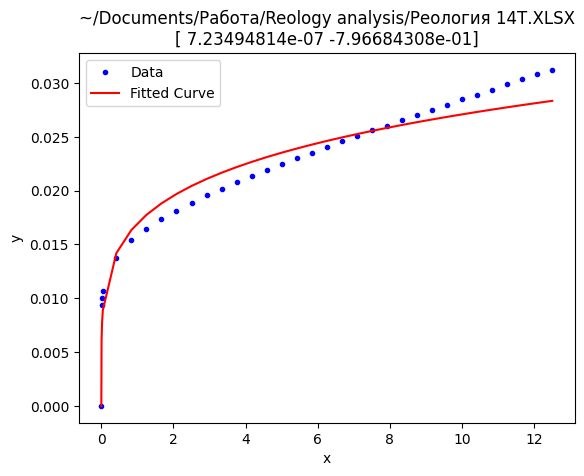

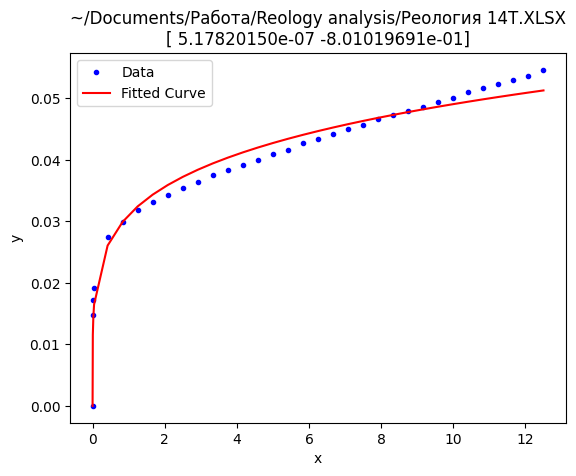

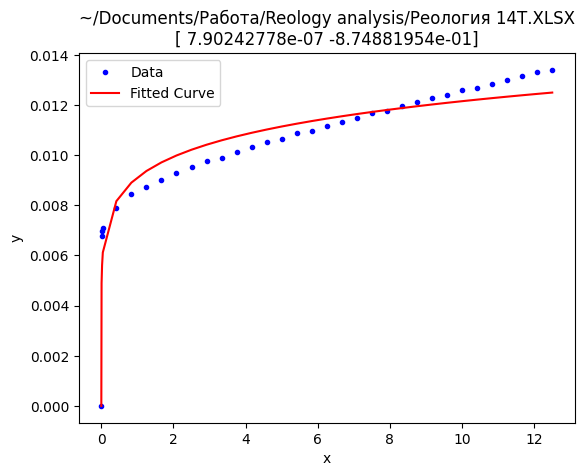

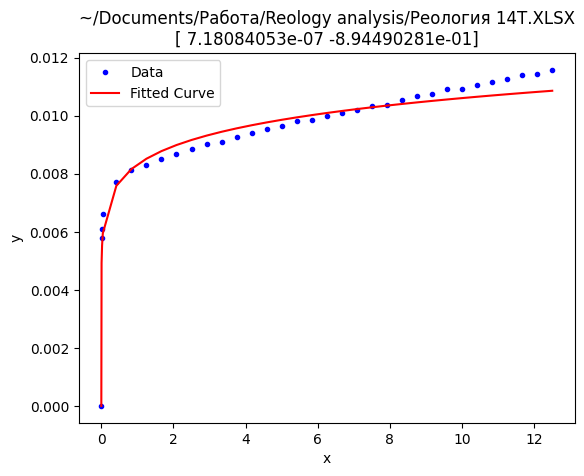

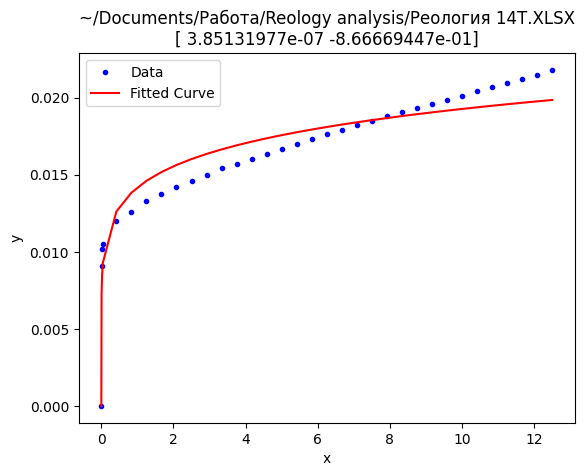

In [23]:
def custom_equation(x, A, m):
    n = 2.964428890433537
    y = A / (m + 1) * sig_int ** n * x ** (m + 1)
    return y


def objective_function(parameters, x, y):
    predicted_values = custom_equation(x, *parameters)
    
    residuals = predicted_values - y
    
    objective = np.sum(residuals**2)
    
    return objective


def optimize_curve(params):
    initial_guess = params

    result = minimize(objective_function, initial_guess, args=(x, y))

    optimal_parameters = result.x

    return optimal_parameters
        
        
coeff_a = []
coeff_m = []
for path in filepaths:
    data = pd.read_excel(ospath(path), None)
    for table in data:
        prepare_data(data[table])
        x = np.array(data[table]['time'])
        sig_int = data[table]['s_i'].max()
        y = np.array(data[table]['e_i'])
        
        optimal_parameters = [a, -0.5]
        
        new_params = optimize_curve(optimal_parameters)
        i = 0
        while all(x != y for x, y in zip(optimal_parameters, new_params)):
            optimal_parameters = new_params
            new_params = optimize_curve(optimal_parameters)
            i += 1
        else:
            optimal_parameters = new_params
            
        coeff_a.append(optimal_parameters[0])
        coeff_m.append(optimal_parameters[1])
        

        fitted_curve = custom_equation(x, *optimal_parameters)

        plt.plot(x, y, 'b.', label='Data')
        plt.plot(x, fitted_curve, 'r-', label='Fitted Curve')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'{path}\n{optimal_parameters}')
        plt.legend()
        plt.show()

Проверяется количество полученных коэффициентов.

In [24]:
a = pd.Series(coeff_a).mean()
m = pd.Series(coeff_m).mean()

len(coeff_a)

199

Финальный результат: средние значения коэффициентов, исопльзуемые в расчете.

In [25]:
print(f'A = {a}, n = {n}, m = {m}')

A = 6.908921278388921e-07, n = 3.3262049379405894, m = -0.8012247901212507
